# Module Load

In [39]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns
from scipy.stats import linregress
from statsmodels.formula.api import mixedlm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import numpy as np






# Functions


## Describe a column

In [40]:

def describe_column(column_name):
    # Describe the column
    description = redcap[column_name].describe()
    print(description)
    
    # Count the number of NaN values in the column
    nan_count = redcap[column_name].isna().sum()
    print(f"Number of NaN values: {nan_count}")

# Example usage
#describe_column('redcap_survey_identifier')

# Data load and prep

## Load Raw Participant file

In [41]:

# Load the CSV file
file_path = 'C:\\Users\\Patrick\\Gutbrain_R\\data\\GUTBRAIN_DATA_2024-12-11_1856.csv'
redcap = pd.read_csv(file_path)


## Prepare participant file for GI analysis

In [42]:
#tfeq_columns = [col for col in redcap.columns if 'tfeq' in col]
redcap.rename(columns={'fteq38': 'tfeq38'}, inplace=True)

# Create a DataFrame with rows that have missing values in any of the 'tfeq' columns
#tfeq_nan = redcap[redcap[tfeq_columns].isna().any(axis=1)][['session', 'id_recherchescan', 'q3', 'redcap_survey_identifier'] + tfeq_columns]

#tfeq_nan.to_csv('tfeq_nan.csv', index=False)

# Convert all string values in the dataframe to lowercase
redcap = redcap.applymap(lambda x: x.lower() if isinstance(x, str) else x)

# Find and deal with missing values in the 'id_recherchescan' column
nan_id_recherchescan = redcap[redcap['id_recherchescan'].isna()]['record_id'].unique()

# Update 'id_recherchescan' for specific 'record_id' values

redcap.loc[redcap['record_id'] == 1, 'id_recherchescan'] = 'rcx096'
redcap.loc[redcap['record_id'] == 6, 'id_recherchescan'] = 'rcx097'
redcap.loc[redcap['record_id'] == 18, 'id_recherchescan'] = 'rnd015'
redcap.loc[redcap['record_id'] == 22, 'id_recherchescan'] = 'rcx136'
redcap.loc[redcap['record_id'] == 35, 'id_recherchescan'] = 'rnd027'
redcap.loc[redcap['record_id'] == 45, 'id_recherchescan'] = 'rcx211'

# Remove rows with 'record_id' 67 and 113
redcap = redcap[~redcap['record_id'].isin([67, 113])]

# Define cols as a list of column names from the redcap DataFrame
cols = list(redcap.columns)

# Create a new column 'session' from 'redcap_event_name'
redcap['session'] = redcap['redcap_event_name']

# Change session values according to the specified logic
redcap['session'] = redcap['session'].map({
    'baseline_arm_1': 1,
    '4_mois_arm_1': 2,
    '12_mois_arm_1': 3,
    '24_mois_arm_1': 4,
    'long_term_arm_1': 5
})

# Drop rows where redcap_event_name is 'long_term_arm_1'
redcap = redcap[redcap['redcap_event_name'] != 'long_term_arm_1']

# Rename session to 'x' if id_participant contains 'rgc' and session is 2
redcap.loc[redcap['id_recherchescan'].str.contains('rgc') & (redcap['session'] == 2), 'session'] = 'x'

# Rename session to 2 if id_participant contains 'rgc' and session is 3
redcap.loc[redcap['id_recherchescan'].str.contains('rgc') & (redcap['session'] == 3), 'session'] = 2

# Create a df called redcap_only_RGC
redcap_only_RGC = redcap[redcap['id_recherchescan'].str.contains('rgc', na=False)]

# Drop rows where id_recherchescan contains rgc
redcap = redcap[~redcap['id_recherchescan'].str.contains('rgc', na=False)]

# Find unique combinations of sessions and id_recherchescan in tfeq_nan
#unique_combinations_nan_tfeq = tfeq_nan[['session', 'id_recherchescan']].drop_duplicates()

# Create a new column called id_participant, which is equal to id_recherchescan
redcap['id_participant'] = redcap['id_recherchescan']

# Ensure the 'session' column is a string
redcap['session'] = redcap['session'].astype(str)







C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\3699652498.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  redcap = redcap.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\3699652498.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'x' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  redcap.loc[redcap['id_recherchescan'].str.contains('rgc') & (redcap['session'] == 2), 'session'] = 'x'


## Prepare GI hormones dataframe

In [43]:
redcap_GI = redcap.copy()



In [44]:

# Load the CSV file into a DataFrame
file_path = 'C:\\Users\\Patrick\\Gutbrain_R\\data\\hormones_GI_gutbrain.csv'
hormones_GI_gutbrain = pd.read_csv(file_path)

# RND0013 correction

hormones_GI_gutbrain['Identification Patient'] = hormones_GI_gutbrain['Identification Patient'].replace('RND0013', 'RND013')
# RND0012, RND0014, RND0015 correction
hormones_GI_gutbrain['Identification Patient'] = hormones_GI_gutbrain['Identification Patient'].replace({'RND0012': 'RND012', 'RND0014': 'RND014', 'RND0015': 'RND015'})

# Create a new column 'id_participant' which is the lowercase of 'Identification Patient'
hormones_GI_gutbrain['id_participant'] = hormones_GI_gutbrain['Identification Patient'].str.lower()

# Create a new column 'session' based on the values in the 'Temps' column
hormones_GI_gutbrain['session'] = hormones_GI_gutbrain['Temps'].map({'BL': 1, '4m': 2, '12m': 3, '24m': 4})

# Create a new column 'fed_state' based on the values in the 'Colonne1' column
hormones_GI_gutbrain['fed_state'] = hormones_GI_gutbrain['Colonne1'].map({'0': 'ac', 'T0': 'ac', 'T60': 'pp', '60': 'pp'})

# replace PYY values labeled '<2,0' with 1
hormones_GI_gutbrain['PYY'] = hormones_GI_gutbrain['PYY'].replace('<2,0', 1)

# Find rows where PYY is less than 2.0
filtered_rows_PYY_less_2 = hormones_GI_gutbrain[hormones_GI_gutbrain['PYY']=='<2,0' ]

# Convert the 'session' column to string type
hormones_GI_gutbrain['session'] = hormones_GI_gutbrain['session'].astype(str)

# Remove the '.0' substring from the 'session' column
hormones_GI_gutbrain['session'] = hormones_GI_gutbrain['session'].str.replace('.0', '', regex=False)

# Convert the 'PYY' column to float type
hormones_GI_gutbrain['PYY'] = hormones_GI_gutbrain['PYY'].astype(float)

# Display the first few rows of the DataFrame
hormones_GI_gutbrain.describe(include=[object])

# Remove rows where 'id_participant' is NaN
hormones_GI_gutbrain = hormones_GI_gutbrain.dropna(subset=['id_participant'])

# Create a copy of hormones_GI_gutbrain for rows where id_participant includes the string 'rgc'
hormones_GI_gutbrain_RGC = hormones_GI_gutbrain[hormones_GI_gutbrain['id_participant'].str.contains('rgc')].copy()

# Remove those rows from hormones_GI_gutbrain
hormones_GI_gutbrain = hormones_GI_gutbrain[~hormones_GI_gutbrain['id_participant'].str.contains('rgc')]

# Remove columns 'ID', 'Identification Patient', 'Temps', 'Colonne1'
hormones_GI_gutbrain = hormones_GI_gutbrain.drop(columns=['ID', 'Identification Patient', 'Temps', 'Colonne1'])

# Rename columns
hormones_GI_gutbrain = hormones_GI_gutbrain.rename(columns={'GLP-1 total': 'GLP_1_total'})

# Rename columns
hormones_GI_gutbrain = hormones_GI_gutbrain.rename(columns={'Ghrelin \nUnacylated': 'Ghrelin_Unacylated'})

# Rename columns
hormones_GI_gutbrain = hormones_GI_gutbrain.rename(columns={'Ghrelin \nacylated': 'Ghrelin_acylated'})




In [45]:


# Extract unique combinations of session and id_participant from redcap_GI
redcap_GI_unique = redcap_GI[['session', 'id_participant']].drop_duplicates()

# Extract unique combinations of session and id_participant from hormones_GI_gutbrain
hormones_GI_gutbrain_unique = hormones_GI_gutbrain[['session', 'id_participant']].drop_duplicates()

# Find unique combinations in redcap_GI that are not in hormones_GI_gutbrain
unique_combinations = redcap_GI_unique.merge(hormones_GI_gutbrain_unique, on=['session', 'id_participant'], how='left', indicator=True)
unique_combinations = unique_combinations[unique_combinations['_merge'] == 'left_only'].drop(columns=['_merge'])
print(unique_combinations)

    session id_participant
36        1         rnd008
37        2         rnd008
38        3         rnd008
39        4         rnd008
72        1         rnd017
..      ...            ...
343       4         rnd074
344       1         rnd076
345       2         rnd076
346       3         rnd076
347       4         rnd076

[100 rows x 2 columns]


Merge both dfs

In [46]:

# Assuming hormones_GI_gutbrain and redcap_GI are already defined as DataFrames
redcap_GI = pd.merge(hormones_GI_gutbrain, redcap_GI, on=['id_participant', 'session'])



## Load Raw Bid File

In [47]:

# Load the file into a DataFrame
file_path = 'C:\\Users\\Patrick\\Gutbrain_R\\data\\avg_bid_and_Nan.csv'
bid_avg_hi_lo = pd.read_csv(file_path)
# Remove the 'sexe' column if it exists
if 'sexe' in bid_avg_hi_lo.columns:
    bid_avg_hi_lo = bid_avg_hi_lo.drop(columns=['sexe'])
# Extend type_chx for the same values of id_participant
bid_avg_hi_lo['type_chx'] = bid_avg_hi_lo.groupby('id_participant')['type_chx'].transform(lambda x: x.ffill().bfill())
# Remove columns containing 'tx_t2d'
bid_avg_hi_lo = bid_avg_hi_lo.loc[:, ~bid_avg_hi_lo.columns.str.contains('tx_t2d')]
# Remove the specified columns if they exist
columns_to_remove = ['date_irm', 'bi_ttaille_scan', 'bi_thanche_scan_x']
columns_to_remove += [col for col in bid_avg_hi_lo.columns if 'MCQ' in col or 'DDT' in col]
columns_to_remove += [
    'poids_bioimp_dance_x', 'vas_faim', 'vas_faim', 'bi_thanche_scan_y', 'bi_tcou_scan_y', 'bioimpedance_scan_complete',
    'grandeur_recherche', 'poids_bioimp_dance_y', 'imc_recherche_y', 'wl_recherche_y', 'ewl_recherche_y', 'twl_recherche_y',
    'asrs_tot_dx', 'asrs_a', 'asrs_dx', 'asrs_b', 'bdi_total', 'gr_bdi_intensity', 'gr_bdi', 'bes_total', 'bes_intensity',
    'yfas_subs', 'yfas_quit', 'yfas_time', 'yfas_act', 'yfas_with', 'yfas_impair', 'yfas_cons', 'yfas_tol', 'yfas_probl',
    'yfas_fail', 'yfas_hazard', 'yfas_crav', 'yfas_symp', 'yfas_dx', 'yfas_dxsev', 'fcqt_int', 'fcqt_reinf', 'fcqt_relief',
    'fcqt_cont', 'fcqt_preoc', 'fcqt_crav', 'fcqt_emo', 'fcqt_cues', 'fcqt_guilt', 'fcqt_total', 'neoffi_neu', 'neoffi_ext',
    'neoffi_op', 'neoffi_agr', 'neoffi_con', 'pfs_avail', 'pfs_pres', 'pfs_tasted', 'pfs_total', 'spsrq_pun', 'spsrq_rew',
    'tfeq_restrt', 'tfeq_restrf', 'tfeq_restrr', 'tfeq_restrc', 'tfeq_dist', 'tfeq_dish', 'tfeq_dise', 'tfeq_diss',
    'tfeq_hungert', 'tfeq_hungeri', 'tfeq_hungere', 'upps_urg', 'upps_premed', 'upps_persev', 'upps_sens'
]
bid_avg_hi_lo = bid_avg_hi_lo.drop(columns=columns_to_remove, errors='ignore')

# Remove rows where 'onset_bid' is NaN
bid_avg_hi_lo = bid_avg_hi_lo.dropna(subset=['onset_bid'])

# Ensure 'session' column is of type string
bid_avg_hi_lo['session'] = bid_avg_hi_lo['session'].astype(str)

bid_avg_hi_lo['IMC_baseline'] = bid_avg_hi_lo.groupby('id_participant', observed=False)['imc_recherche_x'].transform(lambda x: x.iloc[0])


# Extend 'sexeF' and 'type_chx' to all sessions of the same participant from session 1
bid_avg_hi_lo['sexeF'] = bid_avg_hi_lo.groupby('id_participant')['sexeF'].transform(lambda x: x.iloc[0])
bid_avg_hi_lo['type_chx'] = bid_avg_hi_lo.groupby('id_participant')['type_chx'].transform(lambda x: x.iloc[0])

# Ensure 'sexeF' and 'type_chx' columns are categorical
bid_avg_hi_lo['sexeF'] = bid_avg_hi_lo['sexeF'].astype('category')
bid_avg_hi_lo['type_chx'] = bid_avg_hi_lo['type_chx'].astype('category')



In [48]:
bid_avg_hi = bid_avg_hi_lo[bid_avg_hi_lo['calories'] != 'lo']
bid_avg_lo = bid_avg_hi_lo[bid_avg_hi_lo['calories'] != 'hi']

In [49]:
# Assuming bid_avg_hi_lo is already defined and available in the notebook

# Merge bid_avg_hi_lo with redcap_GI, prioritizing redcap_GI columns
df_GI_bid = pd.merge(hormones_GI_gutbrain, bid_avg_hi_lo, on=['id_participant', 'session'], how='left', suffixes=('', '_dup'))

# Drop duplicated columns from bid_avg_hi_lo
df_GI_bid = df_GI_bid.loc[:, ~df_GI_bid.columns.str.endswith('_dup')]





In [50]:
df_GI_bid['Ghrelin_Totale'] = df_GI_bid['Ghrelin_Unacylated'] + df_GI_bid['Ghrelin_acylated']

In [51]:

columns_to_zscore = ['GLP_1_total', 'Leptin', 'PYY', 'Ghrelin_Unacylated', 'Ghrelin_acylated','Ghrelin_Totale']

df_GI_bid_no_outlier = df_GI_bid.copy()

for column in columns_to_zscore:
    df_GI_bid[column + '_zscore'] = zscore(df_GI_bid[column], nan_policy='omit')
df_GI_bid

zscore_columns = [column + '_zscore' for column in columns_to_zscore]

df_GI_bid_no_outlier = df_GI_bid[
    (df_GI_bid[zscore_columns] <= 3).all(axis=1) & 
    (df_GI_bid[zscore_columns] >= -3).all(axis=1)
]
df_GI_bid_no_outlier


,GLP_1_total,Leptin,PYY,Ghrelin_Unacylated,Ghrelin_acylated,id_participant,session,fed_state,calories,Donnees utilisee pour CMDO,...,Prix/gramme,Commentaire.1,IMC_baseline,Ghrelin_Totale,GLP_1_total_zscore,Leptin_zscore,PYY_zscore,Ghrelin_Unacylated_zscore,Ghrelin_acylated_zscore,Ghrelin_Totale_zscore
0,83.1,11.47,9.18,382.93,77.61,rcx096,1,ac,hi,1.0,...,0.030102,NaN,35.817711,460.54,0.037145,0.038763,-0.747203,1.007179,0.237886,0.710152
1,83.1,11.47,9.18,382.93,77.61,rcx096,1,ac,lo,1.0,...,NaN,NaN,35.817711,460.54,0.037145,0.038763,-0.747203,1.007179,0.237886,0.710152
2,126.3,9.45,18.21,269.70,29.78,rcx096,1,pp,hi,1.0,...,0.030102,NaN,35.817711,299.48,0.639828,-0.158829,-0.546027,0.441958,-0.108658,0.222113
3,126.3,9.45,18.21,269.70,29.78,rcx096,1,pp,lo,1.0,...,NaN,NaN,35.817711,299.48,0.639828,-0.158829,-0.546027,0.441958,-0.108658,0.222113
4,35.9,2.61,15.90,311.22,58.94,rcx096,2,ac,hi,1.0,...,0.030102,NaN,35.817711,370.16,-0.621341,-0.827906,-0.597490,0.649217,0.102616,0.436285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,33.5,28.08,23.16,126.00,44.12,rnd062,1,ac,lo,1.0,...,NaN,NaN,51.801461,170.12,-0.654824,1.663523,-0.435747,-0.275365,-0.004760,-0.169870
946,28.2,22.46,10.96,98.44,45.00,rnd062,1,pp,hi,1.0,...,0.030471,NaN,51.801461,143.44,-0.728764,1.113785,-0.707547,-0.412939,0.001616,-0.250715
947,28.2,22.46,10.96,98.44,45.00,rnd062,1,pp,lo,1.0,...,NaN,NaN,51.801461,143.44,-0.728764,1.113785,-0.707547,-0.412939,0.001616,-0.250715
948,22.3,2.03,35.32,68.56,32.28,rnd062,2,ac,NaN,NaN,...,NaN,NaN,NaN,100.84,-0.811075,-0.884640,-0.164838,-0.562094,-0.090545,-0.379800


## Create df_GI_bid_hi_ac

In [52]:
# Create a new df based on fasted state and bid for hi calorie foods

df_GI_bid_hi_ac = df_GI_bid.copy()
df_GI_bid_hi_ac = df_GI_bid_hi_ac[(df_GI_bid_hi_ac['fed_state'] == 'ac') & (df_GI_bid_hi_ac['calories'] == 'hi')]



### Create dfs for ghreline Total AC

In [53]:
# Find participants and sessions where Ghrelin_Totale is not recorded (AC, HI)
df_no_Ghrelin_Totale = df_GI_bid_hi_ac[df_GI_bid_hi_ac['Ghrelin_Totale'].isna()][['id_participant', 'session']].drop_duplicates()
#print(df_no_Ghrelin_Totale)

# Create a DF where there are no Nans for Ghrelin_Totale AC HI
df_GI_bid_hi_ac_Ghrelin_Totale = df_GI_bid_hi_ac.dropna(subset=['Ghrelin_Totale'])

# Calculate z-scores for Ghrelin_Totale and session
df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore_session'] = df_GI_bid_hi_ac_Ghrelin_Totale.groupby('session')['Ghrelin_Totale'].transform(lambda x: (x - x.mean()) / x.std())
df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore'] = zscore(df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale'])
df_GI_bid_hi_ac_Ghrelin_Totale['log_Ghrelin_Totale'] = np.log(df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale'])

#print(df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore_session'])
# Save the DataFrame to a CSV file
df_GI_bid_hi_ac_Ghrelin_Totale.to_csv('df_GI_bid_hi_ac_Ghrelin_Totale.csv', index=False)

# Print Ghrelin_Totale_zscore_session and Ghrelin_Totale_zscore
#print(df_GI_bid_hi_ac_Ghrelin_Totale[['Ghrelin_Totale_zscore_session', 'Ghrelin_Totale_zscore']])

#print(basic_stat(df_GI_bid_hi_ac_Ghrelin_Totale))

# Find outliers based on Ghrelin_Totale zscore
outliers_Ghrelin_Totale = df_GI_bid_hi_ac_Ghrelin_Totale[(df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore'] > 3) | (df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore'] < -3)]
print(outliers_Ghrelin_Totale[['id_participant', 'session']])

# Find outliers based on Ghrelin_Totale zscore per session
outliers_Ghrelin_Totale_session = df_GI_bid_hi_ac_Ghrelin_Totale[(df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore_session'] > 3) | (df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore_session'] < -3)]
print(outliers_Ghrelin_Totale_session[['id_participant', 'session']])

# Remove outliers based on z-score threshold of 3
df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers = df_GI_bid_hi_ac_Ghrelin_Totale[df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore'].abs() <= 3]
#print(basic_stat(df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers))

# Remove outliers based on z-score threshold of 3 for session
df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session = df_GI_bid_hi_ac_Ghrelin_Totale[df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore_session'].abs() <= 3]
#print(basic_stat(df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session))



    id_participant session
802         rnd050       1
806         rnd050       2
    id_participant session
170         rnd001       4
802         rnd050       1
806         rnd050       2
810         rnd050       3


C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\593832382.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore_session'] = df_GI_bid_hi_ac_Ghrelin_Totale.groupby('session')['Ghrelin_Totale'].transform(lambda x: (x - x.mean()) / x.std())
C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\593832382.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_Totale_zscore'] = zscore(df_GI_bid_hi_ac_Ghrelin_Totale['Ghrelin_

## Create df_GI_bid_hi_ac_no_outlier

In [54]:
df_GI_bid_hi_ac_no_outlier = df_GI_bid_no_outlier.copy()
df_GI_bid_hi_ac_no_outlier = df_GI_bid_hi_ac_no_outlier[(df_GI_bid_hi_ac_no_outlier['fed_state'] == 'ac') & (df_GI_bid_hi_ac['calories'] == 'hi')]


C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\753173571.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_GI_bid_hi_ac_no_outlier = df_GI_bid_hi_ac_no_outlier[(df_GI_bid_hi_ac_no_outlier['fed_state'] == 'ac') & (df_GI_bid_hi_ac['calories'] == 'hi')]


## Create df_GI_bid_hi_pp

In [55]:
df_GI_bid_hi_pp = df_GI_bid.copy()
df_GI_bid_hi_pp = df_GI_bid_hi_pp[(df_GI_bid_hi_pp['fed_state'] == 'pp') & (df_GI_bid_hi_pp['calories'] == 'hi')]


### Create dfs GLP1 PP

In [56]:
# Find participants and sessions where GLP1 is not recorded (PP)
df_no_GLP_1_total_pp = df_GI_bid_hi_pp[df_GI_bid_hi_pp['GLP_1_total'].isna()][['id_participant', 'session']].drop_duplicates()
#print(df_no_GLP_1_total_pp)

# Create a DF where there are no Nans for GLP1 PP
df_GI_bid_hi_pp_GLP1 = df_GI_bid_hi_pp.dropna(subset=['GLP_1_total'])

# Calculate z-scores for GLP_1_total and session
df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore_session'] = df_GI_bid_hi_pp_GLP1.groupby('session')['GLP_1_total'].transform(lambda x: (x - x.mean()) / x.std())
df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore'] = zscore(df_GI_bid_hi_pp_GLP1['GLP_1_total'])
#print(df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore_session'])

# Print GLP_1_total_zscore_session and GLP_1_total_zscore
#print(df_GI_bid_hi_pp_GLP1[['GLP_1_total_zscore_session', 'GLP_1_total_zscore']])

#print(basic_stat(df_GI_bid_hi_pp_GLP1))

# Find outliers based on GLP1 zscore
outliers_GLP1_pp = df_GI_bid_hi_pp_GLP1[(df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore'] > 3) | (df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore'] < -3)]
print(outliers_GLP1_pp[['id_participant', 'session']])

# Find outliers based on GLP1 zscore per session
outliers_GLP1_session_pp = df_GI_bid_hi_pp_GLP1[(df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore_session'] > 3) | (df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore_session'] < -3)]
print(outliers_GLP1_session_pp[['id_participant', 'session']])

# Remove outliers based on z-score threshold of 3
df_GI_bid_hi_pp_GLP1_no_outliers = df_GI_bid_hi_pp_GLP1[df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore'].abs() <= 3]
#print(basic_stat(df_GI_bid_hi_pp_GLP1_no_outliers))

# Remove outliers based on z-score threshold of 3 for session
df_GI_bid_hi_pp_GLP1_no_outliers_session = df_GI_bid_hi_pp_GLP1[df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore_session'].abs() <= 3]
#print(basic_stat(df_GI_bid_hi_pp_GLP1_no_outliers_session))

# Create new DataFrames for each session
df_GI_bid_hi_pp_GLP1_ses_1 = df_GI_bid_hi_pp_GLP1[df_GI_bid_hi_pp_GLP1['session'] == '1']
df_GI_bid_hi_pp_GLP1_ses_2 = df_GI_bid_hi_pp_GLP1[df_GI_bid_hi_pp_GLP1['session'] == '2']
df_GI_bid_hi_pp_GLP1_ses_3 = df_GI_bid_hi_pp_GLP1[df_GI_bid_hi_pp_GLP1['session'] == '3']
df_GI_bid_hi_pp_GLP1_ses_4 = df_GI_bid_hi_pp_GLP1[df_GI_bid_hi_pp_GLP1['session'] == '4']

# Create new DataFrames for each session based on df_GI_bid_hi_pp_GLP1_no_outliers_session
df_GI_bid_hi_pp_GLP1_no_outliers_session_ses_1 = df_GI_bid_hi_pp_GLP1_no_outliers_session[df_GI_bid_hi_pp_GLP1_no_outliers_session['session'] == '1']
df_GI_bid_hi_pp_GLP1_no_outliers_session_ses_2 = df_GI_bid_hi_pp_GLP1_no_outliers_session[df_GI_bid_hi_pp_GLP1_no_outliers_session['session'] == '2']
df_GI_bid_hi_pp_GLP1_no_outliers_session_ses_3 = df_GI_bid_hi_pp_GLP1_no_outliers_session[df_GI_bid_hi_pp_GLP1_no_outliers_session['session'] == '3']
df_GI_bid_hi_pp_GLP1_no_outliers_session_ses_4 = df_GI_bid_hi_pp_GLP1_no_outliers_session[df_GI_bid_hi_pp_GLP1_no_outliers_session['session'] == '4']



    id_participant session
102         rcx164       2
142         rcx211       4
146         rcx219       1
    id_participant session
142         rcx211       4
146         rcx219       1


C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\1304928128.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore_session'] = df_GI_bid_hi_pp_GLP1.groupby('session')['GLP_1_total'].transform(lambda x: (x - x.mean()) / x.std())
C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\1304928128.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GI_bid_hi_pp_GLP1['GLP_1_total_zscore'] = zscore(df_GI_bid_hi_pp_GLP1['GLP_1_total'])


### Create DFs for PYY PP

In [57]:
# Find participants and sessions where PYY is not recorded (PP)
df_no_PYY_pp = df_GI_bid_hi_pp[df_GI_bid_hi_pp['PYY'].isna()][['id_participant', 'session']].drop_duplicates()
#print(df_no_PYY_pp)

# Create a DF where there are no Nans for PYY PP
df_GI_bid_hi_pp_PYY = df_GI_bid_hi_pp.dropna(subset=['PYY'])

# Calculate z-scores for PYY and session
df_GI_bid_hi_pp_PYY['PYY_zscore_session'] = df_GI_bid_hi_pp_PYY.groupby('session')['PYY'].transform(lambda x: (x - x.mean()) / x.std())
df_GI_bid_hi_pp_PYY['PYY_zscore'] = zscore(df_GI_bid_hi_pp_PYY['PYY'])
#print(df_GI_bid_hi_pp_PYY['PYY_zscore_session'])

# Print PYY_zscore_session and PYY_zscore
#print(df_GI_bid_hi_pp_PYY[['PYY_zscore_session', 'PYY_zscore']])

#print(basic_stat(df_GI_bid_hi_pp_PYY))

# Find outliers based on PYY zscore
outliers_PYY_pp = df_GI_bid_hi_pp_PYY[(df_GI_bid_hi_pp_PYY['PYY_zscore'] > 3) | (df_GI_bid_hi_pp_PYY['PYY_zscore'] < -3)]
print(outliers_PYY_pp[['id_participant', 'session']])

# Find outliers based on PYY zscore per session
outliers_PYY_session_pp = df_GI_bid_hi_pp_PYY[(df_GI_bid_hi_pp_PYY['PYY_zscore_session'] > 3) | (df_GI_bid_hi_pp_PYY['PYY_zscore_session'] < -3)]
print(outliers_PYY_session_pp[['id_participant', 'session']])

# Remove outliers based on z-score threshold of 3
df_GI_bid_hi_pp_PYY_no_outliers = df_GI_bid_hi_pp_PYY[df_GI_bid_hi_pp_PYY['PYY_zscore'].abs() <= 3]
#print(basic_stat(df_GI_bid_hi_pp_PYY_no_outliers))

# Remove outliers based on z-score threshold of 3 for session
df_GI_bid_hi_pp_PYY_no_outliers_session = df_GI_bid_hi_pp_PYY[df_GI_bid_hi_pp_PYY['PYY_zscore_session'].abs() <= 3]
#print(basic_stat(df_GI_bid_hi_pp_PYY_no_outliers_session))

    id_participant session
804         rnd050       1
808         rnd050       2
812         rnd050       3
    id_participant session
804         rnd050       1
808         rnd050       2
812         rnd050       3


C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\1671900560.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GI_bid_hi_pp_PYY['PYY_zscore_session'] = df_GI_bid_hi_pp_PYY.groupby('session')['PYY'].transform(lambda x: (x - x.mean()) / x.std())
C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\1671900560.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_GI_bid_hi_pp_PYY['PYY_zscore'] = zscore(df_GI_bid_hi_pp_PYY['PYY'])


## Create df_GI_bid_hi_pp_no_outlier

In [58]:
df_GI_bid_hi_pp_no_outlier = df_GI_bid_no_outlier.copy()
df_GI_bid_hi_pp_no_outlier = df_GI_bid_hi_pp_no_outlier[(df_GI_bid_hi_pp_no_outlier['fed_state'] == 'pp') & (df_GI_bid_hi_pp['calories'] == 'hi')]

C:\Users\Patrick\AppData\Local\Temp\ipykernel_4120\3358801601.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_GI_bid_hi_pp_no_outlier = df_GI_bid_hi_pp_no_outlier[(df_GI_bid_hi_pp_no_outlier['fed_state'] == 'pp') & (df_GI_bid_hi_pp['calories'] == 'hi')]


# Exploratory plots no outlier

### AC , one DF for all plots (less accurate analysis here)

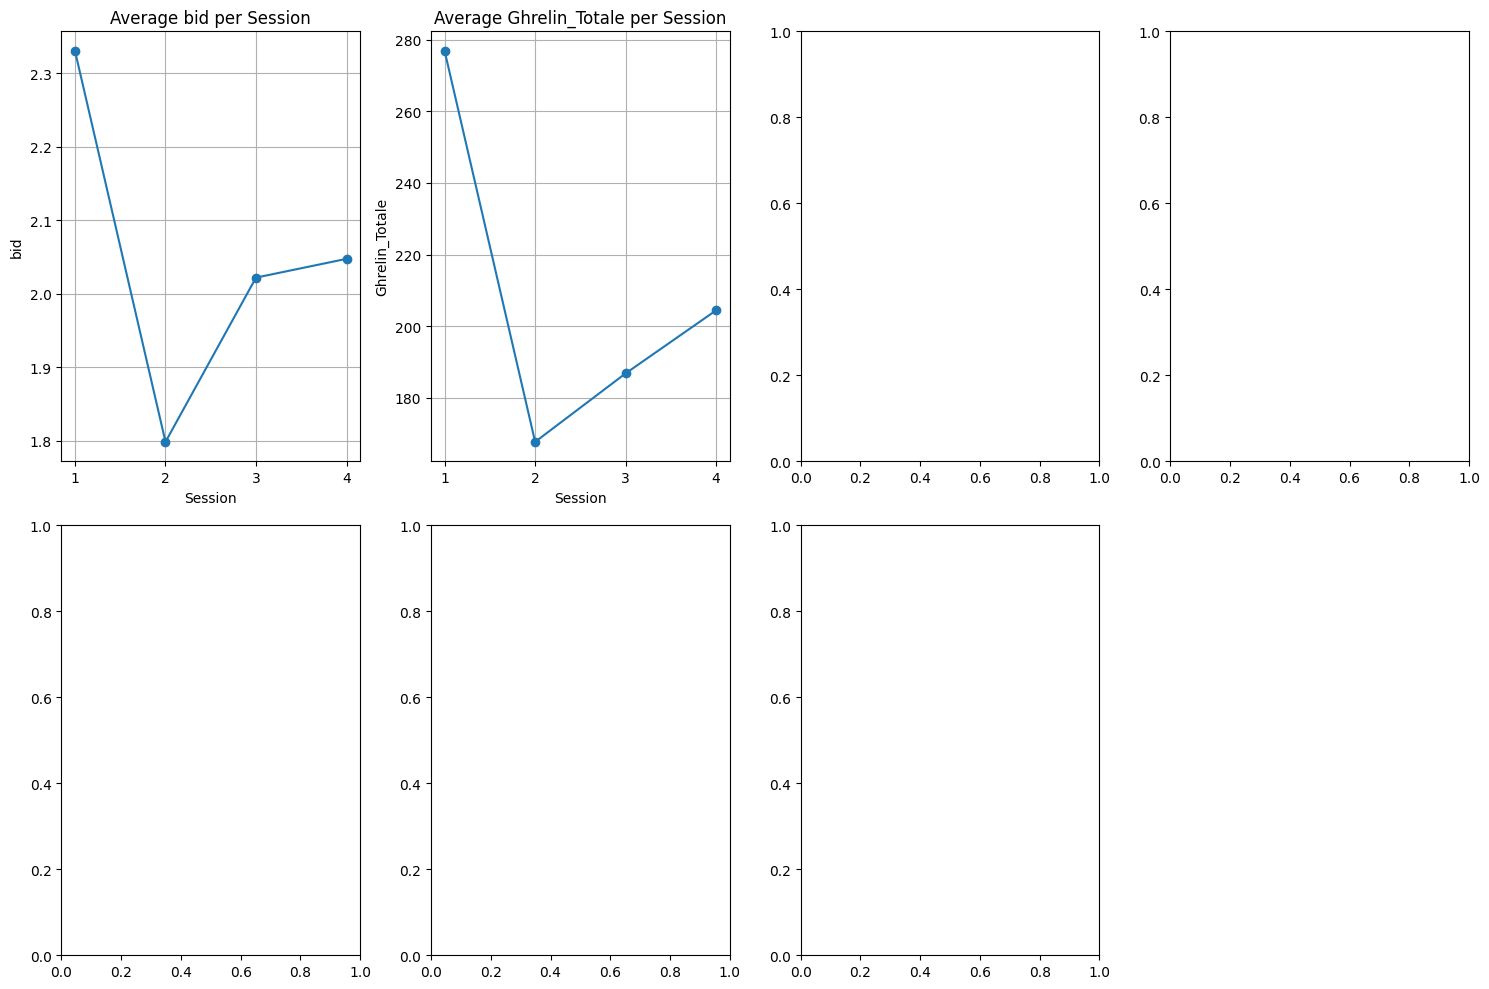

In [59]:
# Assuming df_GI_bid_hi_pp is already defined
columns_to_plot = ['bid','Ghrelin_Totale']

# Calculate the average per session for each column
average_per_session = df_GI_bid_hi_ac_no_outlier.groupby('session')[columns_to_plot].mean()

# Create a matrix of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i, column in enumerate(columns_to_plot):
    axes[i].plot(average_per_session.index, average_per_session[column], marker='o')
    axes[i].set_title(f'Average {column} per Session')
    axes[i].set_xlabel('Session')
    axes[i].set_ylabel(column)
    axes[i].grid(True)

# Remove the empty subplot (if any)
if len(columns_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### AC with dfs per hormone

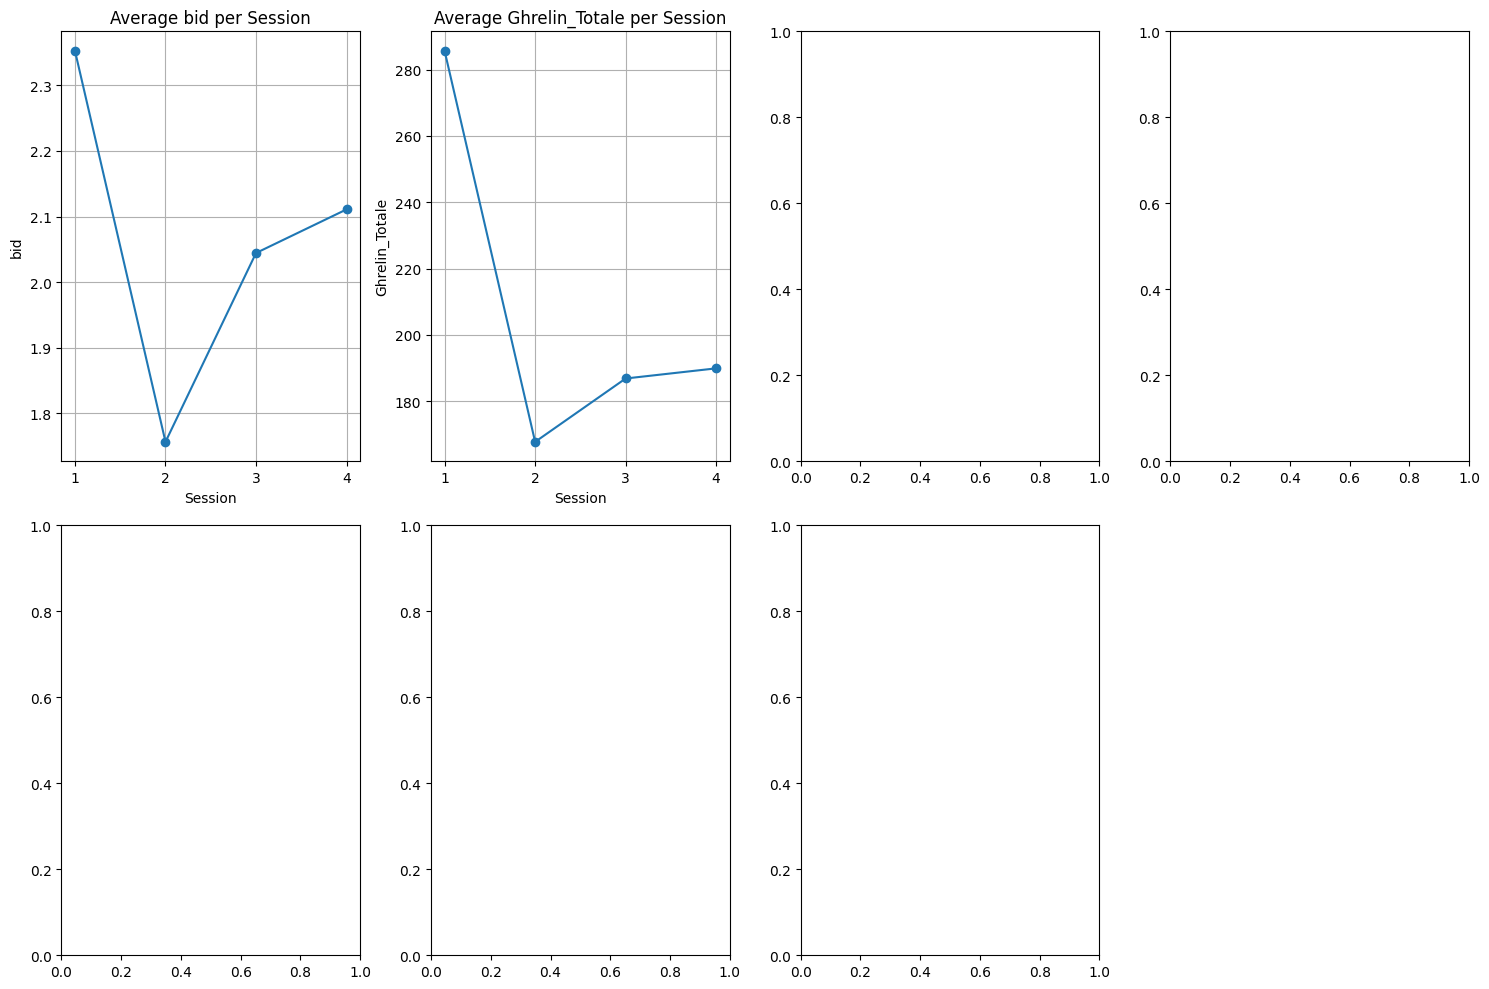

In [60]:
# Define the DataFrames for each column
df_dict = {
    'bid': df_GI_bid_hi_ac,
    'Ghrelin_Totale': df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session
}

# Define the columns to plot
columns_to_plot = ['bid', 'Ghrelin_Totale']

# Create a matrix of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i, column in enumerate(columns_to_plot):
    df = df_dict[column]
    # Calculate the average per session for each column
    average_per_session = df.groupby('session')[column].mean()
    
    axes[i].plot(average_per_session.index, average_per_session, marker='o')
    axes[i].set_title(f'Average {column} per Session')
    axes[i].set_xlabel('Session')
    axes[i].set_ylabel(column)
    axes[i].grid(True)

# Remove the empty subplot (if any)
if len(columns_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Scatter plot one DF for all hormones, no outliers, AC (less accurate analysis)

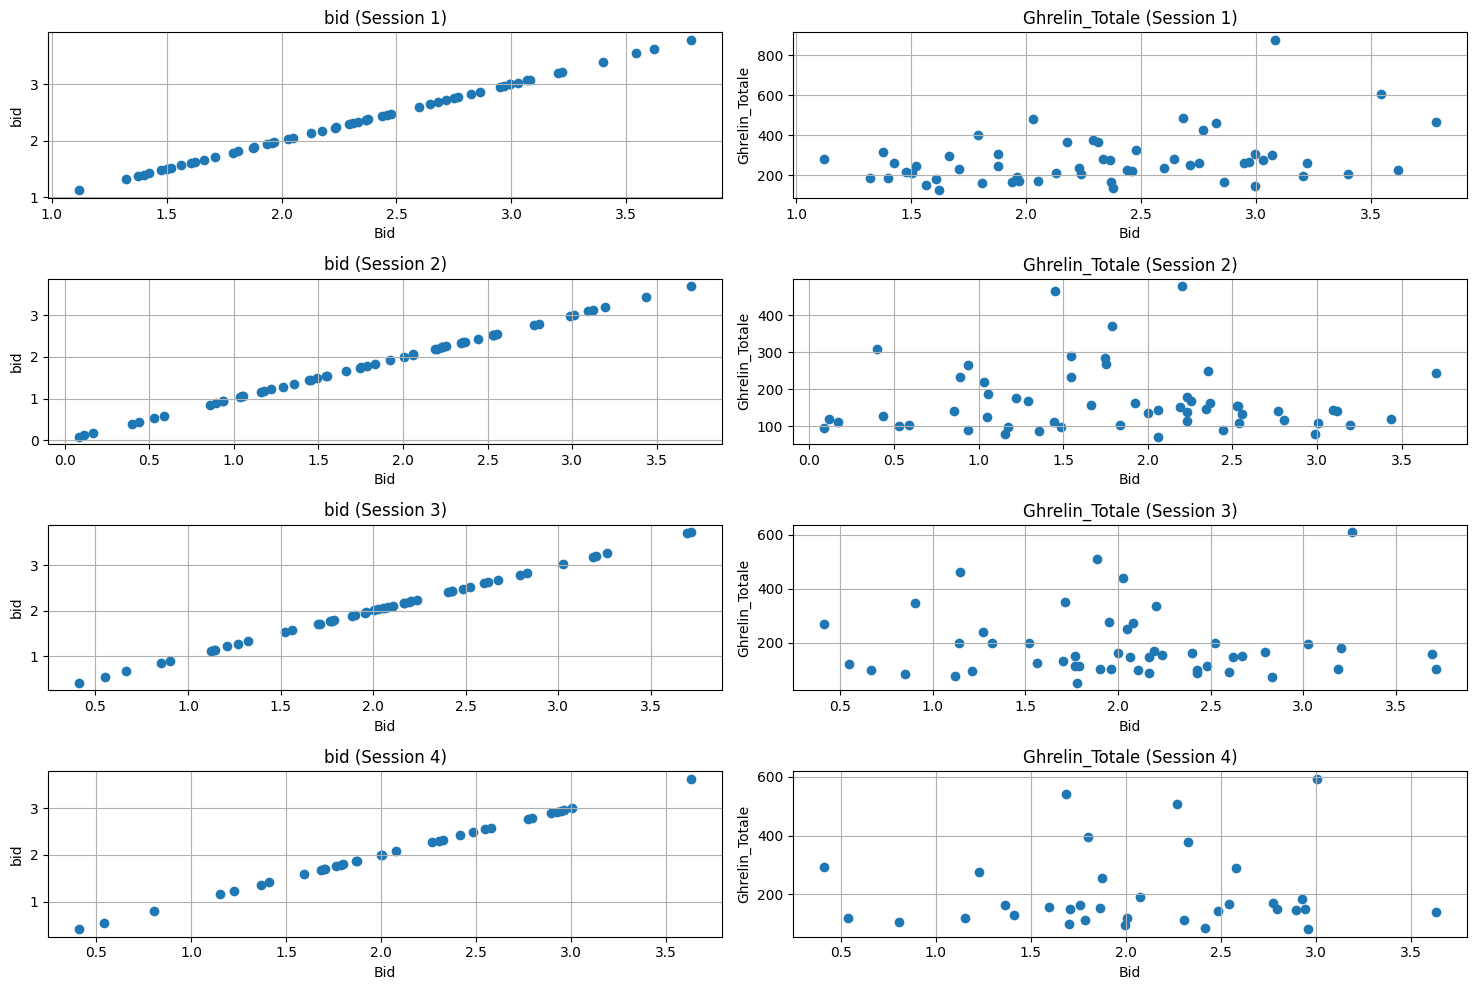

In [61]:
# Assuming df_GI_bid_hi_pp is already defined
columns_to_plot = ['bid', 'Ghrelin_Totale']
sessions = df_GI_bid_hi_ac_no_outlier['session'].unique()

# Determine the grid size
num_sessions = len(sessions)
num_columns = len(columns_to_plot)
fig, axes = plt.subplots(num_sessions, num_columns, figsize=(15, 10))

# Plotting scatter plots for each session and each column
for i, session in enumerate(sessions):
    session_data = df_GI_bid_hi_ac_no_outlier[df_GI_bid_hi_ac_no_outlier['session'] == session]
    for j, column in enumerate(columns_to_plot):
        ax = axes[i, j]
        ax.scatter(session_data['bid'], session_data[column], label=f'Session {session}')
        ax.set_title(f'{column} (Session {session})')
        ax.set_xlabel('Bid')
        ax.set_ylabel(column)
        ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

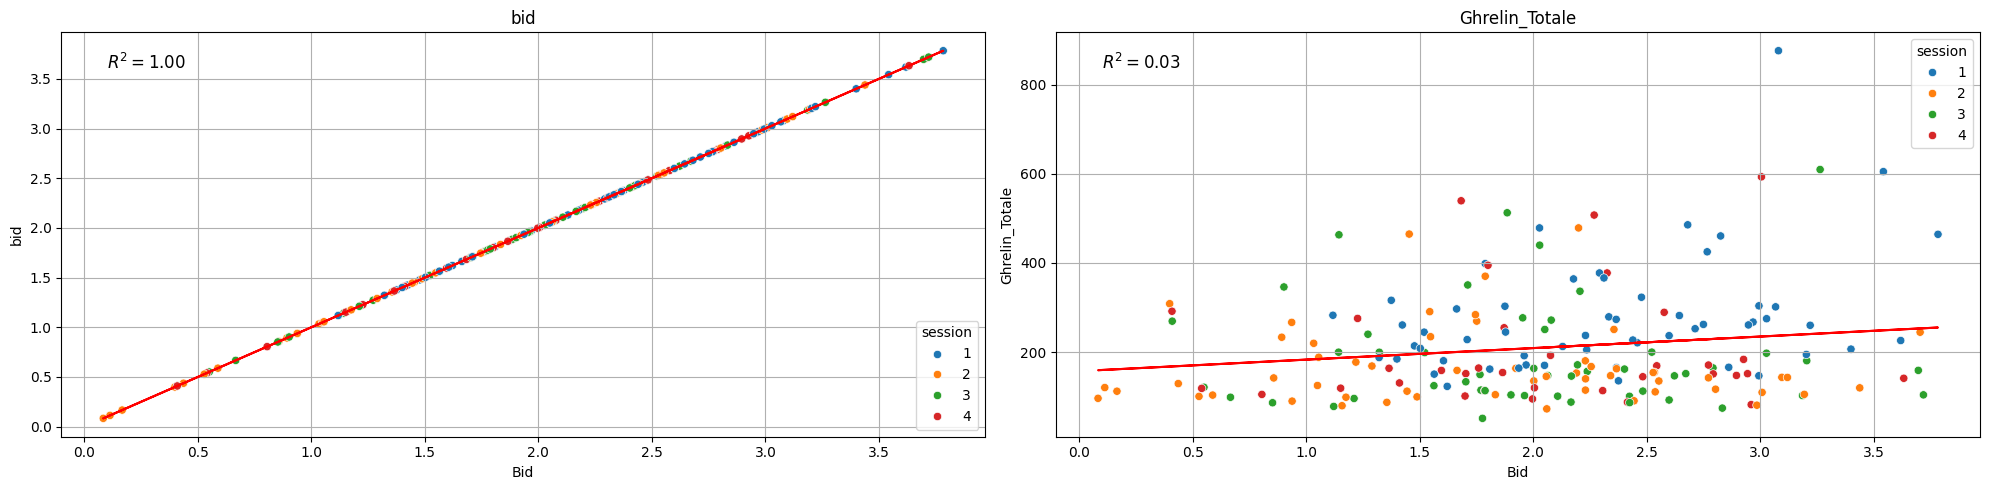

In [62]:
# Assuming df_GI_bid_hi_pp is already defined
columns_to_plot = ['bid', 'Ghrelin_Totale']

# Determine the grid size
num_columns = len(columns_to_plot)
fig, axes = plt.subplots(1, num_columns, figsize=(20, 5))

# Plotting scatter plots for each column with all sessions combined
for i, column in enumerate(columns_to_plot):
    ax = axes[i]
    sns.scatterplot(data=df_GI_bid_hi_ac_no_outlier, x='bid', y=column, hue='session', ax=ax)
    
    # Fit regression line
    slope, intercept, r_value, p_value, std_err = linregress(df_GI_bid_hi_ac_no_outlier['bid'], df_GI_bid_hi_ac_no_outlier[column])
    ax.plot(df_GI_bid_hi_ac_no_outlier['bid'], intercept + slope * df_GI_bid_hi_ac_no_outlier['bid'], color='red')
    
    # Add R² value to the plot
    ax.text(0.05, 0.95, f'$R^2 = {r_value**2:.2f}$', transform=ax.transAxes, fontsize=12, verticalalignment='top')
    
    ax.set_title(f'{column}')
    ax.set_xlabel('Bid')
    ax.set_ylabel(column)
    ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

### Scatterplot, One df per hormone, no outliers AC, better analysis

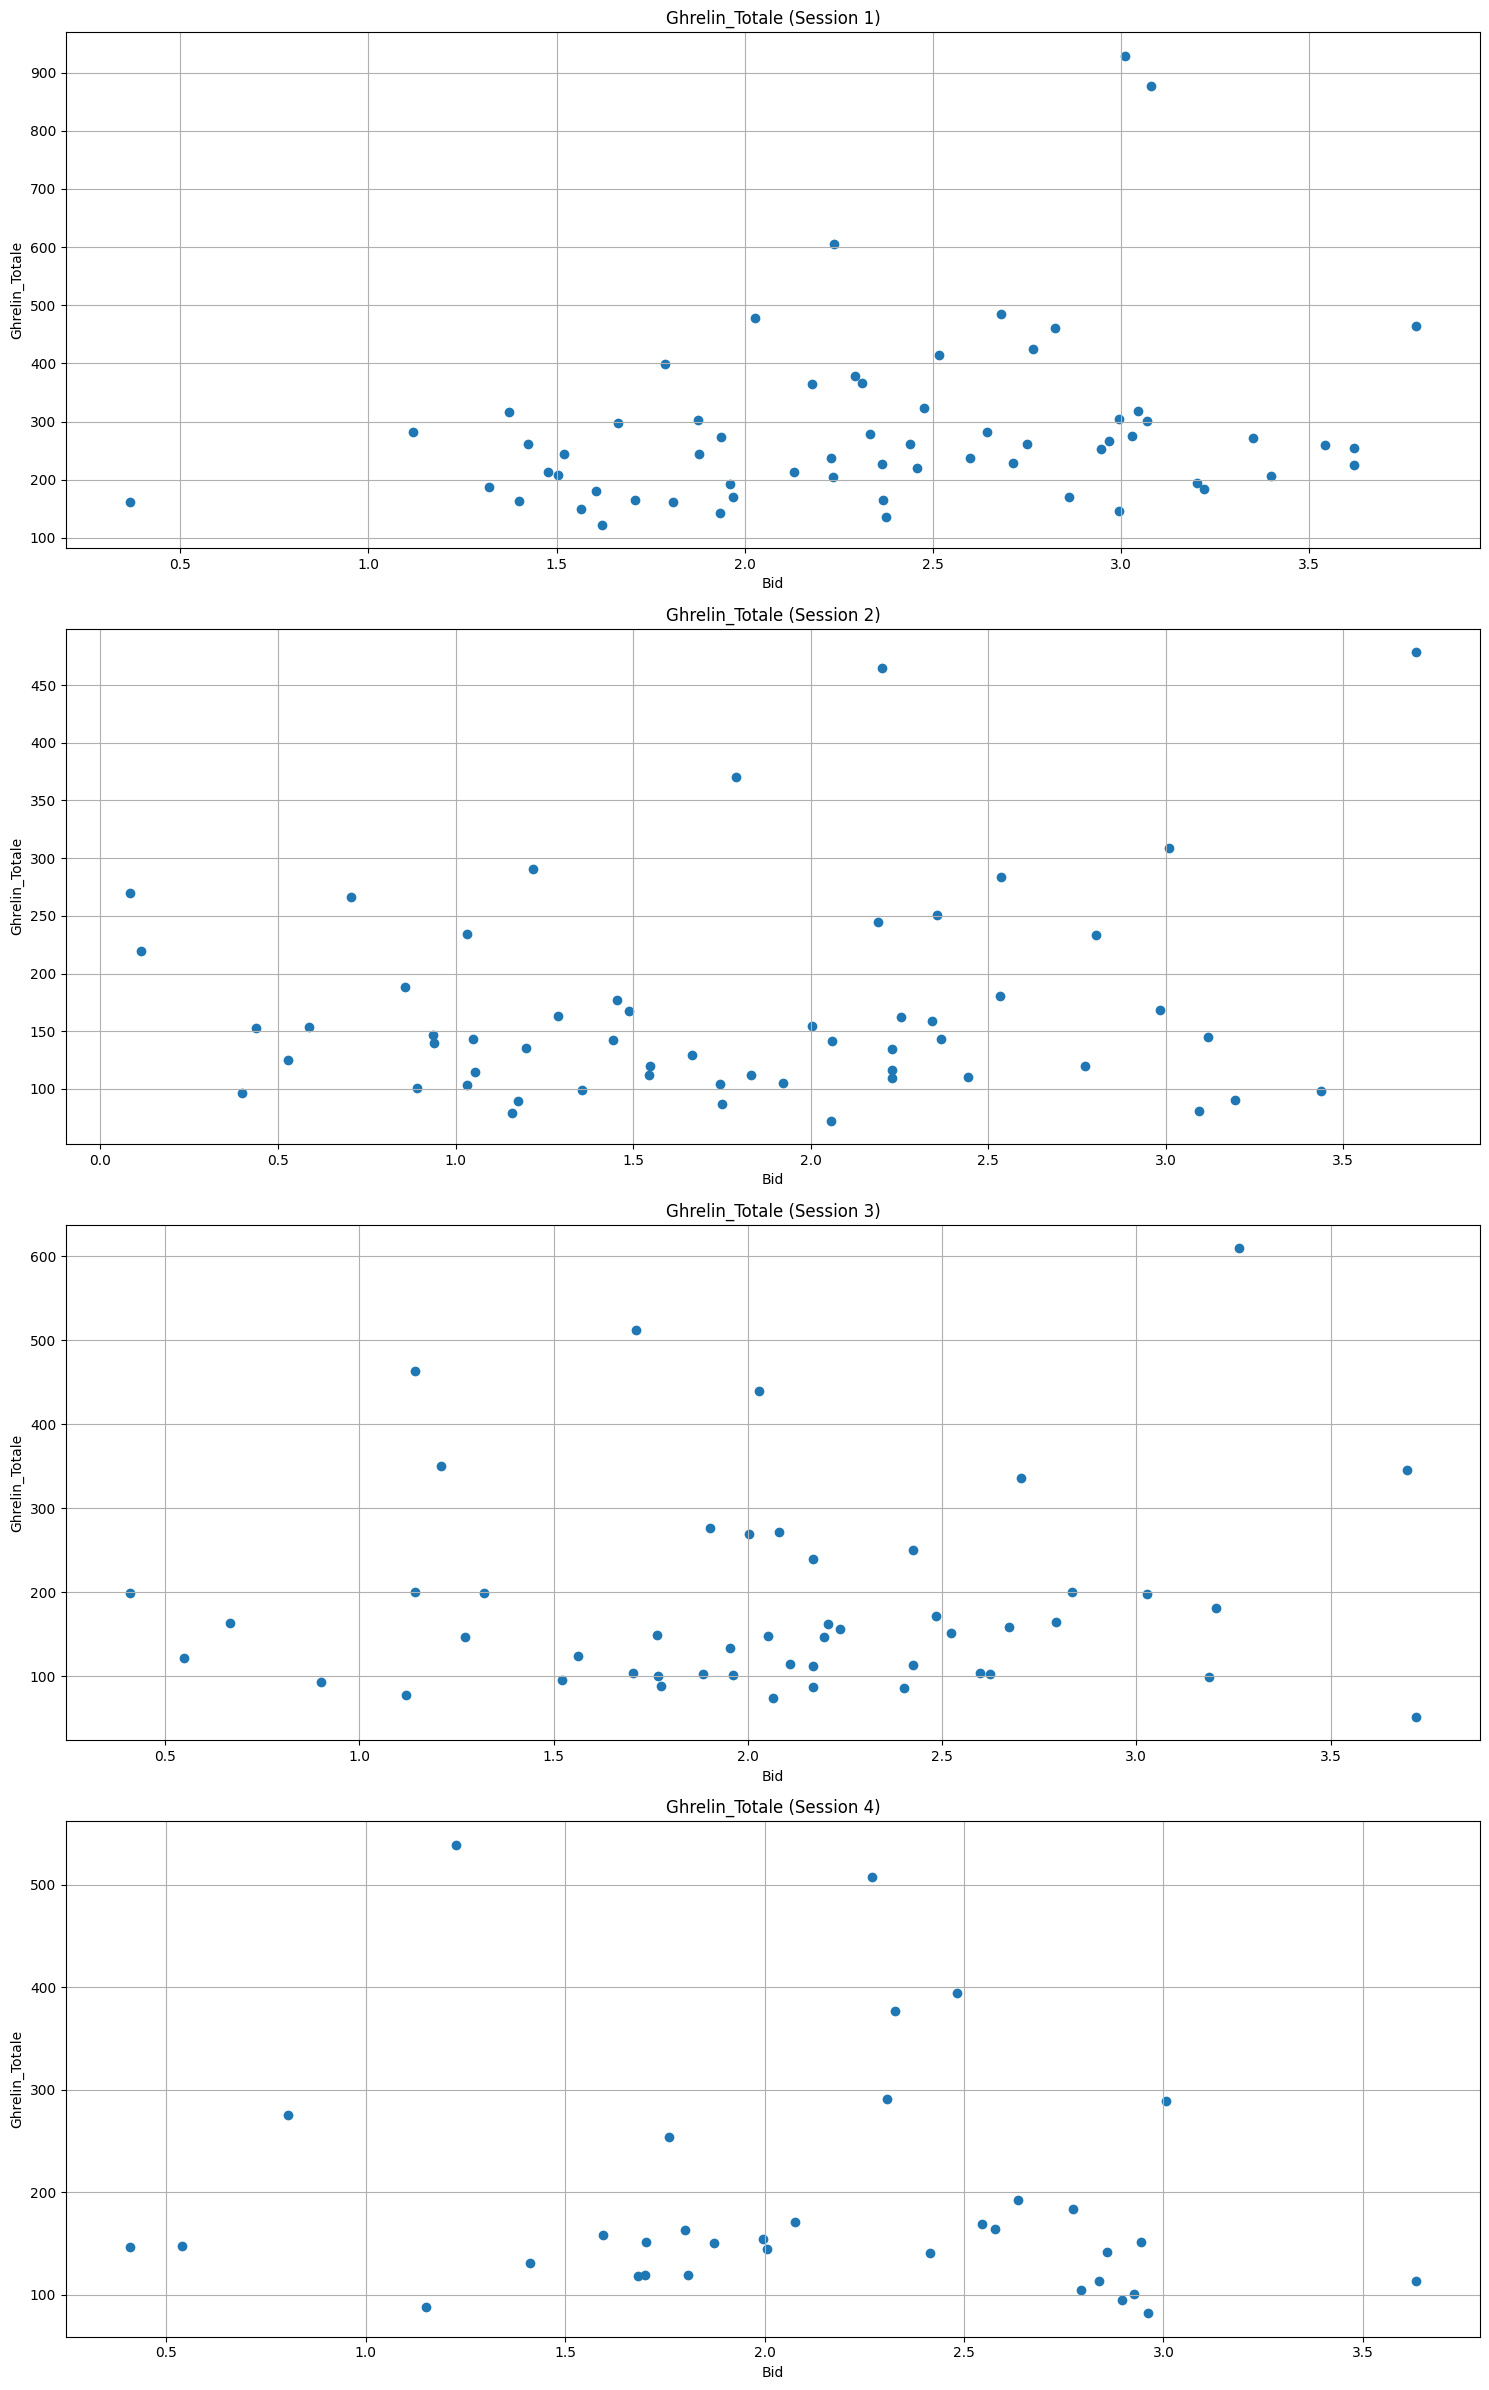

In [63]:

df_dict = {
    'Ghrelin_Totale': df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session
}

columns_to_plot = ['Ghrelin_Totale']
sessions = df_GI_bid_hi_ac['session'].dropna().unique()

if len(sessions) > 0:
    fig, axes = plt.subplots(len(sessions), len(columns_to_plot), figsize=(15, 6 * len(sessions)), squeeze=False)

    for i, session in enumerate(sessions):
        for j, column in enumerate(columns_to_plot):
            df_hormone = df_dict[column]
            session_hormone = df_hormone[df_hormone['session'] == session].copy()
            session_bid = df_GI_bid_hi_ac[df_GI_bid_hi_ac['session'] == session][['bid']].copy()

            # reset index so rows align cleanly
            session_hormone = session_hormone[[column]].reset_index(drop=True)
            session_bid = session_bid.reset_index(drop=True)

            merged = pd.concat([session_bid, session_hormone], axis=1).dropna()

            ax = axes[i, j]
            ax.scatter(merged['bid'], merged[column], label=f'Session {session}')
            ax.set_title(f'{column} (Session {session})')
            ax.set_xlabel('Bid')
            ax.set_ylabel(column)
            ax.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("No sessions available to plot.")

### PP, one df for all hormones, not most accurate, no outliers

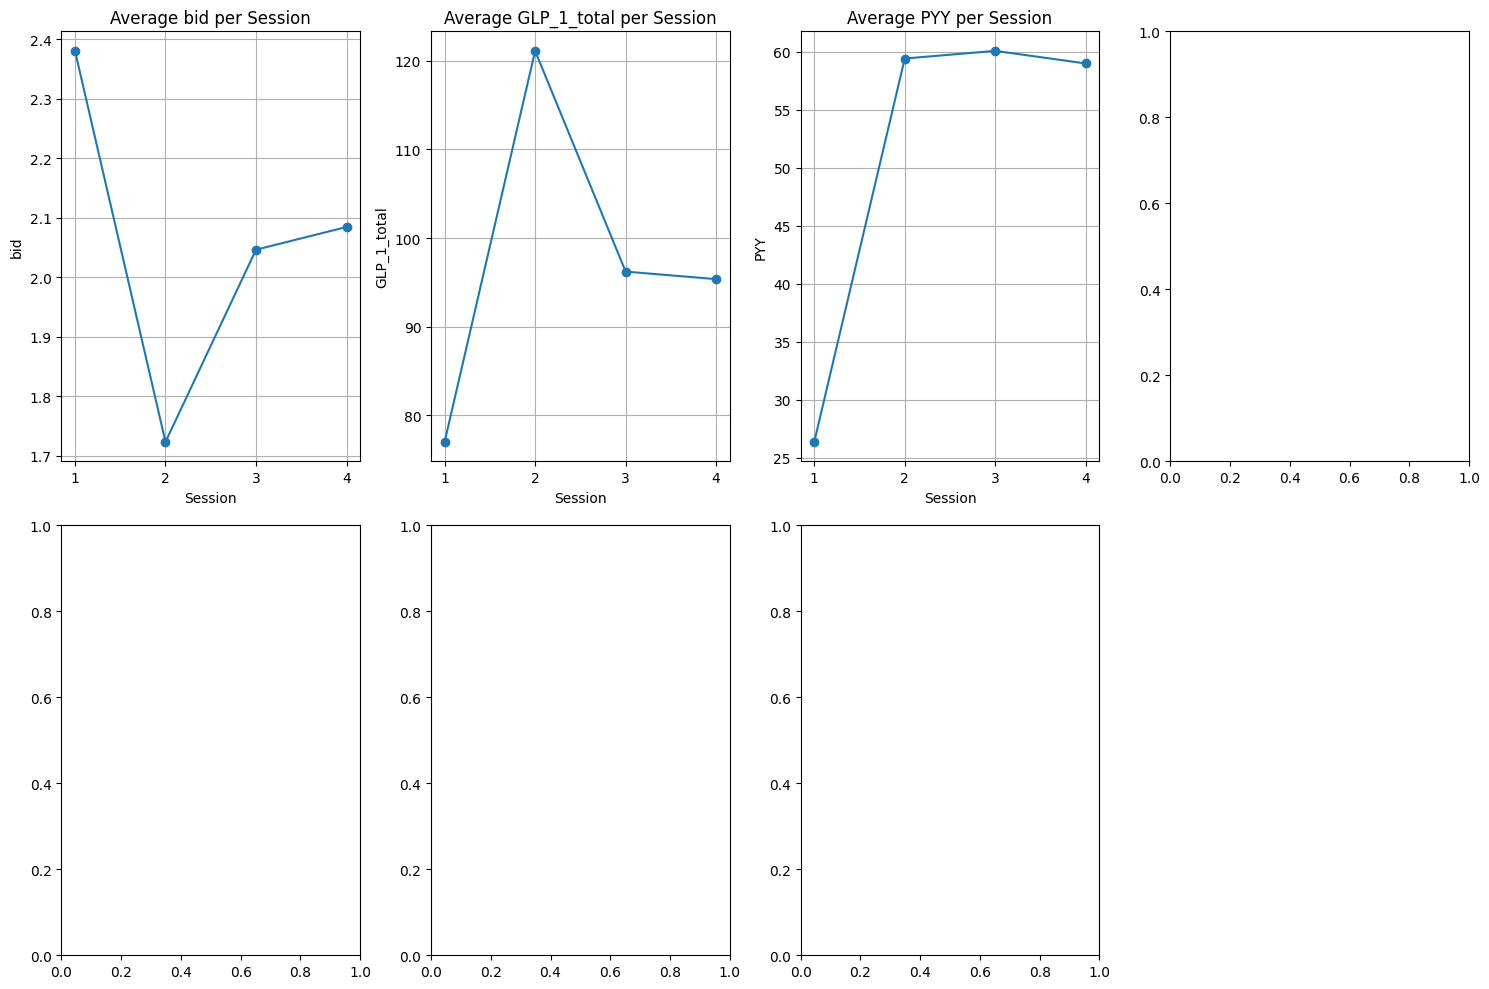

In [64]:
# Assuming df_GI_bid_hi_pp is already defined
columns_to_plot = ['bid','GLP_1_total', 'PYY']

# Calculate the average per session for each column
average_per_session = df_GI_bid_hi_pp_no_outlier.groupby('session')[columns_to_plot].mean()

# Create a matrix of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i, column in enumerate(columns_to_plot):
    axes[i].plot(average_per_session.index, average_per_session[column], marker='o')
    axes[i].set_title(f'Average {column} per Session')
    axes[i].set_xlabel('Session')
    axes[i].set_ylabel(column)
    axes[i].grid(True)

# Remove the empty subplot (if any)
if len(columns_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### PP, no outliers, one DF per hormone (most accurate here)

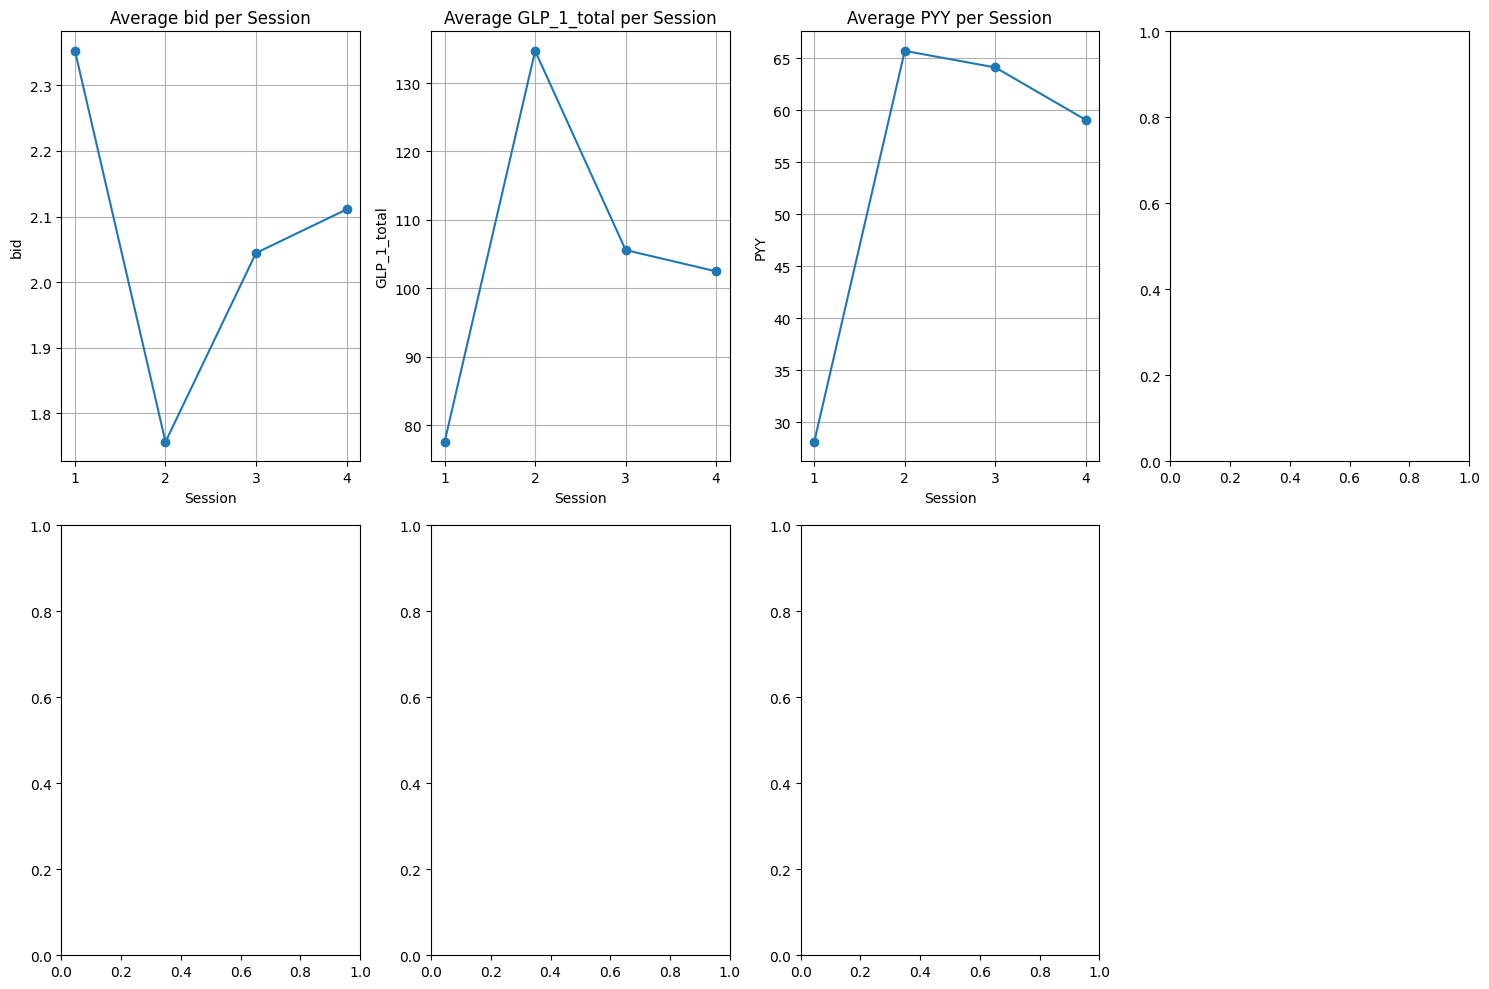

In [65]:
# Define the DataFrames for each column
df_dict = {
    'bid': df_GI_bid_hi_ac,
    'GLP_1_total': df_GI_bid_hi_pp_GLP1_no_outliers_session,
    'PYY': df_GI_bid_hi_pp_PYY_no_outliers_session
    
}

# Define the columns to plot
columns_to_plot = ['bid', 'GLP_1_total', 'PYY']

# Create a matrix of subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plotting
for i, column in enumerate(columns_to_plot):
    df = df_dict[column]
    # Calculate the average per session for each column
    average_per_session = df.groupby('session')[column].mean()
    
    axes[i].plot(average_per_session.index, average_per_session, marker='o')
    axes[i].set_title(f'Average {column} per Session')
    axes[i].set_xlabel('Session')
    axes[i].set_ylabel(column)
    axes[i].grid(True)

# Remove the empty subplot (if any)
if len(columns_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Scatterplot, one df for all (less accurate), PP, no outliers

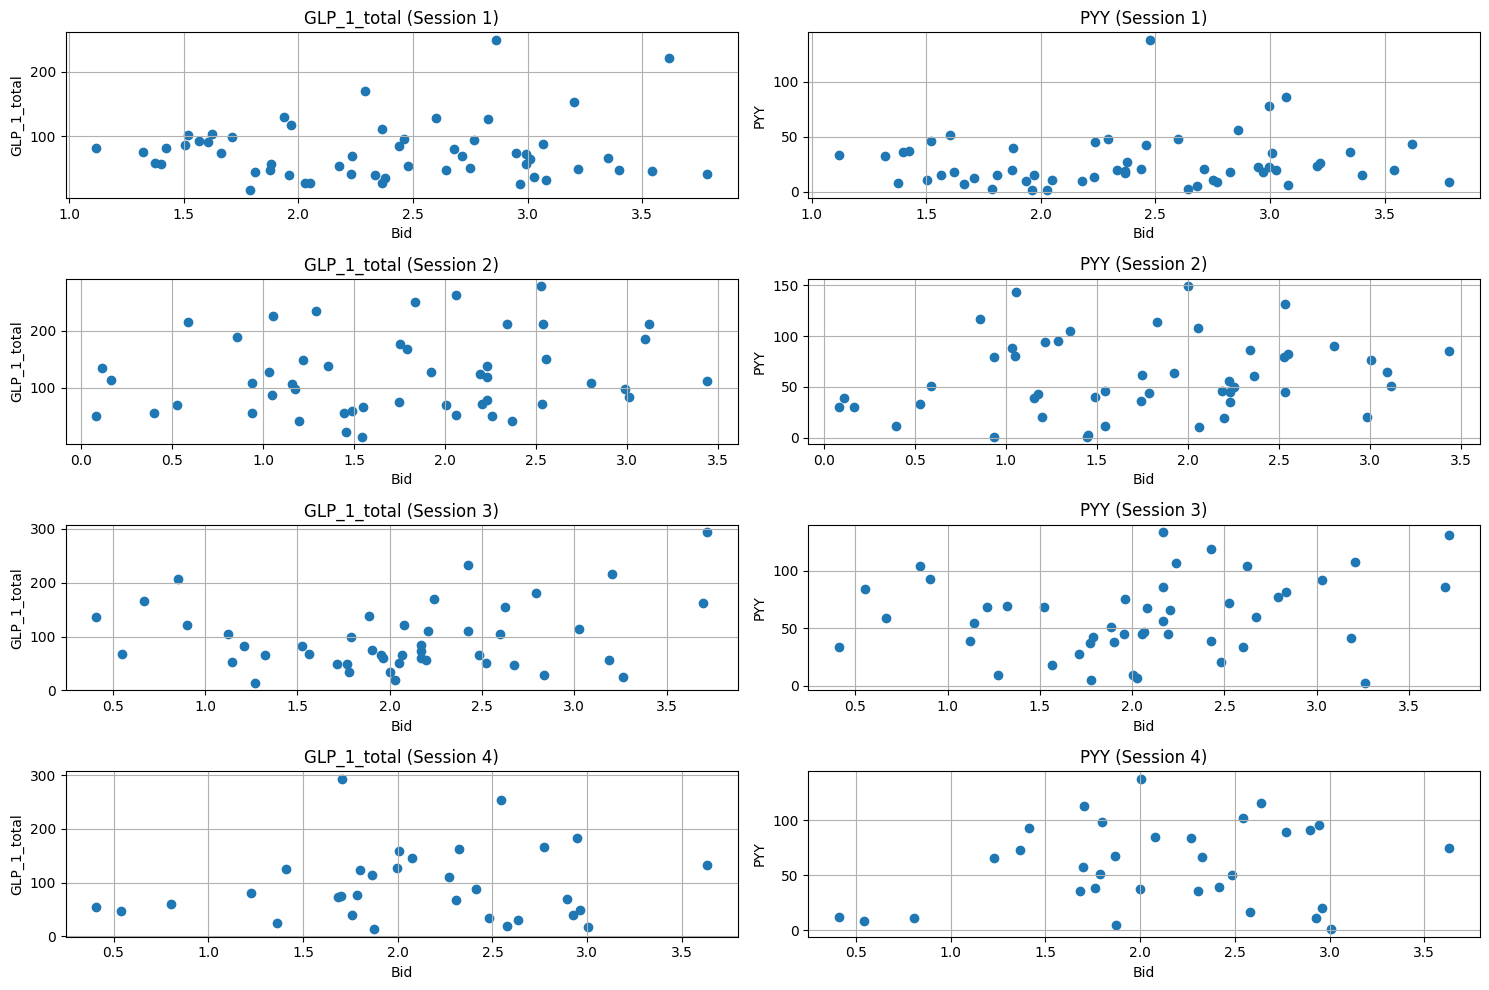

In [66]:
# Assuming df_GI_bid_hi_pp is already defined
columns_to_plot = ['GLP_1_total', 'PYY']
sessions = df_GI_bid_hi_pp_no_outlier['session'].unique()

# Determine the grid size
num_sessions = len(sessions)
num_columns = len(columns_to_plot)
fig, axes = plt.subplots(num_sessions, num_columns, figsize=(15, 10))

# Plotting scatter plots for each session and each column
for i, session in enumerate(sessions):
    session_data = df_GI_bid_hi_pp_no_outlier[df_GI_bid_hi_pp_no_outlier['session'] == session]
    for j, column in enumerate(columns_to_plot):
        ax = axes[i, j]
        ax.scatter(session_data['bid'], session_data[column], label=f'Session {session}')
        ax.set_title(f'{column} (Session {session})')
        ax.set_xlabel('Bid')
        ax.set_ylabel(column)
        ax.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()

### Scatterplot, one df per hormone (most accurate), no outliers, PP

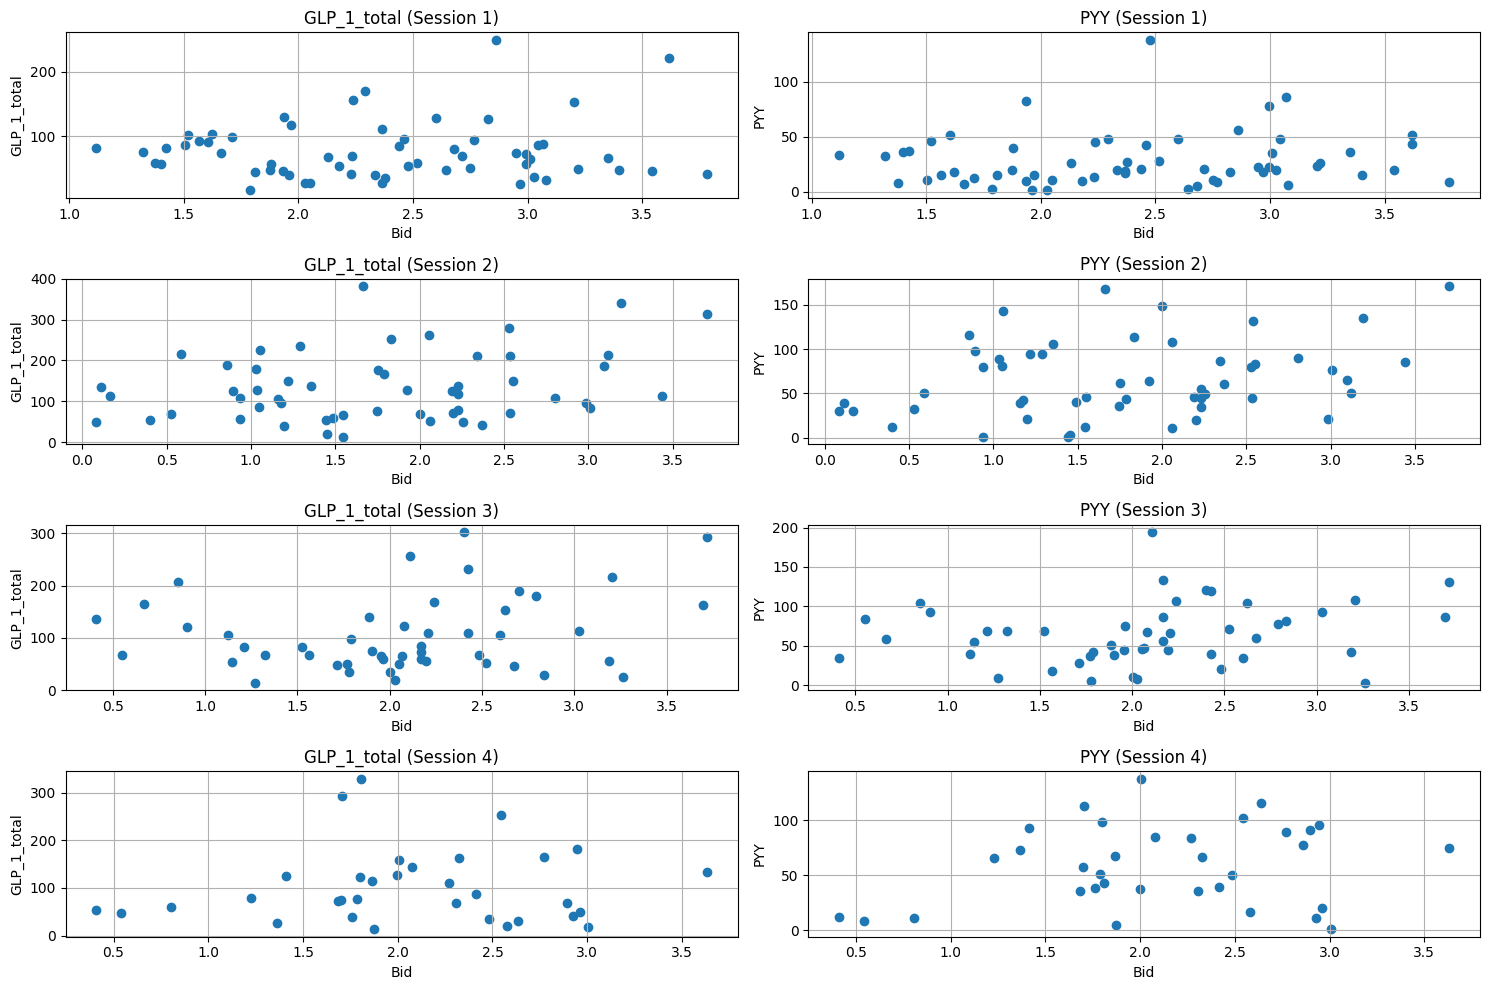

In [67]:
# Define the DataFrames for each column
df_dict = {
    'GLP_1_total': df_GI_bid_hi_pp_GLP1_no_outliers_session,
    'PYY': df_GI_bid_hi_pp_PYY_no_outliers_session
    
}

# Define the columns to plot
columns_to_plot = ['GLP_1_total','PYY']

# Assuming df_GI_bid_hi_pp is already defined
sessions = df_GI_bid_hi_pp['session'].unique()

# Check if there are any sessions available
if len(sessions) > 0:
    # Determine the grid size
    num_sessions = len(sessions)
    num_columns = len(columns_to_plot)
    fig, axes = plt.subplots(num_sessions, num_columns, figsize=(15, 10))

    # Plotting scatter plots for each session and each column
    for i, session in enumerate(sessions):
        for j, column in enumerate(columns_to_plot):
            df = df_dict[column]
            session_data = df[df['session'] == session]
            bid_data = df_GI_bid_hi_pp[df_GI_bid_hi_pp['session'] == session]['bid']
            # Ensure bid_data and session_data[column] have the same length
            common_index = session_data.index.intersection(bid_data.index)
            ax = axes[i, j]
            ax.scatter(bid_data.loc[common_index], session_data.loc[common_index, column], label=f'Session {session}')
            ax.set_title(f'{column} (Session {session})')
            ax.set_xlabel('Bid')
            ax.set_ylabel(column)
            ax.grid(True)

    # Adjust layout
    plt.tight_layout()
    plt.show()
else:
    print("No sessions available to plot.")

# Graphs for paper

## keep only final participant sessions

In [68]:
import pandas as pd
from pathlib import Path

file_path = Path("C:\\Users\\Patrick\\Gutbrain_R\\data\\3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_qc_final.txt")

# Load tab-delimited text file
df_lmer = pd.read_csv(file_path, sep="\t")

print(df_lmer.shape)
display(df_lmer.head())

(507, 10)


,Subj,sess,run,sex,type_chx,handedness,vas_debut,age_baseline,bmi_baseline,InputFile
0,rcx097,1,1,female,3,right,0.073987,-4.134714,0.107199,/home/pagag24/projects/def-amichaud/share/GutB...
1,rcx097,1,2,female,3,right,0.073987,-4.134714,0.107199,/home/pagag24/projects/def-amichaud/share/GutB...
2,rcx097,2,1,female,3,right,-3.162124,-4.134714,0.107199,/home/pagag24/projects/def-amichaud/share/GutB...
3,rcx097,2,2,female,3,right,-3.162124,-4.134714,0.107199,/home/pagag24/projects/def-amichaud/share/GutB...
4,rcx097,2,3,female,3,right,-3.162124,-4.134714,0.107199,/home/pagag24/projects/def-amichaud/share/GutB...


## Clean and rerun Mixed models for results with qc final

In [69]:
import pandas as pd
import statsmodels.formula.api as smf

# -------------------------------
# 1) Build allowed participant-session keys from df_lmer
# -------------------------------
allowed_pairs = (
    df_lmer.loc[:, ["Subj", "sess"]]
    .dropna()
    .drop_duplicates()
    .assign(
        __pid=lambda d: d["Subj"].astype(str).str.strip().str.lower(),
        __sess_code=lambda d: pd.to_numeric(d["sess"], errors="coerce").astype("Int64")
    )[["__pid", "__sess_code"]]
)

# -------------------------------
# 2) Helper to harmonize session coding in your analysis dfs
# -------------------------------
def session_to_code(x):
    # Numeric sessions (1,2,3,4)
    n = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    if pd.notna(n):
        return int(n)

    # String sessions (e.g., pre_chirurgie, 4_mois, 12_mois, 24_mois)
    s = str(x).strip().lower().replace(" ", "").replace("-", "").replace("_", "")
    if "pre" in s:
        return 1
    if "24" in s:
        return 4
    if "12" in s:
        return 3
    if "4" in s:
        return 2
    return pd.NA

def keep_only_lmer_pairs(df_in, id_col="id_participant", session_col="session"):
    df_tmp = df_in.copy()
    df_tmp["__pid"] = df_tmp[id_col].astype(str).str.strip().str.lower()
    df_tmp["__sess_code"] = df_tmp[session_col].apply(session_to_code).astype("Int64")

    df_out = (
        df_tmp.merge(allowed_pairs, on=["__pid", "__sess_code"], how="inner")
              .drop(columns=["__pid", "__sess_code"])
              .reset_index(drop=True)
    )
    return df_out

# -------------------------------
# 3) Create new filtered dfs
# -------------------------------
df_GLP1_lmer = keep_only_lmer_pairs(df_GI_bid_hi_pp_GLP1_no_outliers_session)
df_PYY_lmer = keep_only_lmer_pairs(df_GI_bid_hi_pp_PYY_no_outliers_session)
df_Ghrelin_lmer = keep_only_lmer_pairs(df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session)

print("Rows kept:")
print("GLP1:", df_GLP1_lmer.shape)
print("PYY:", df_PYY_lmer.shape)
print("Ghrelin:", df_Ghrelin_lmer.shape)

# -------------------------------
# 3b) Print N per session
# -------------------------------
def print_n_per_session(df_in, label, session_col="session", id_col="id_participant"):
    counts = (
        df_in.groupby(session_col)
        .agg(
            n_rows=("bid", "size"),
            n_participants=(id_col, "nunique")
        )
        .sort_index()
    )
    print("\n" + "=" * 80)
    print(f"{label} - N per session")
    print("=" * 80)
    print(counts)

print_n_per_session(df_GLP1_lmer, "GLP-1")
print_n_per_session(df_PYY_lmer, "PYY")
print_n_per_session(df_Ghrelin_lmer, "Ghrelin Totale")

# Optional sanity check: unique participant-session pairs
print("\nUnique participant-session pairs kept:")
print("GLP1:", df_GLP1_lmer[["id_participant", "session"]].drop_duplicates().shape[0])
print("PYY:", df_PYY_lmer[["id_participant", "session"]].drop_duplicates().shape[0])
print("Ghrelin:", df_Ghrelin_lmer[["id_participant", "session"]].drop_duplicates().shape[0])

# -------------------------------
# 4) Fit LMMs on filtered dfs
# -------------------------------
results_GLP1 = smf.mixedlm(
    "bid ~ GLP_1_total + age + type_chx + IMC_baseline + sexeF",
    df_GLP1_lmer,
    groups=df_GLP1_lmer["id_participant"],
    re_formula="1"
).fit()

results_PYY = smf.mixedlm(
    "bid ~ PYY + age + type_chx + IMC_baseline + sexeF",
    df_PYY_lmer,
    groups=df_PYY_lmer["id_participant"]
).fit()

results_Ghrelin = smf.mixedlm(
    "bid ~ Ghrelin_Totale + age + type_chx + IMC_baseline + sexeF",
    df_Ghrelin_lmer,
    groups=df_Ghrelin_lmer["id_participant"]
).fit()

print("=" * 80)
print("GLP-1 MODEL")
print("=" * 80)
print(results_GLP1.summary())

print("\n" + "=" * 80)
print("PYY MODEL")
print("=" * 80)
print(results_PYY.summary())

print("\n" + "=" * 80)
print("GHRELIN MODEL")
print("=" * 80)
print(results_Ghrelin.summary())

Rows kept:
GLP1: (147, 46)
PYY: (146, 46)
Ghrelin: (154, 47)

GLP-1 - N per session
         n_rows  n_participants
session                        
1            45              45
2            40              40
3            38              38
4            24              24

PYY - N per session
         n_rows  n_participants
session                        
1            45              45
2            39              39
3            37              37
4            25              25

Ghrelin Totale - N per session
         n_rows  n_participants
session                        
1            47              47
2            41              41
3            39              39
4            27              27

Unique participant-session pairs kept:
GLP1: 147
PYY: 146
Ghrelin: 154
GLP-1 MODEL
          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  bid      
No. Observations:  147      Method:              REML     
No. Groups:        48       Scale:   

## with final QC Pyy = time (table 1)


--- N per session (PYY, filtered on df_lmer pairs) ---
         n_rows  n_participants
session                        
1            45              45
2            39              39
3            37              37
4            25              25
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: PYY      
No. Observations: 146     Method:             REML     
No. Groups:       47      Scale:              581.4989 
Min. group size:  2       Log-Likelihood:     -692.7724
Max. group size:  4       Converged:          Yes      
Mean group size:  3.1                                  
-------------------------------------------------------
              Coef.  Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     29.423    5.057 5.818 0.000 19.511 39.335
session[T.2]  38.001    5.372 7.074 0.000 27.473 48.530
session[T.3]  38.606    5.467 7.061 0.000 27.891 49.322
session[T.4]  36.273    6.307 5.7

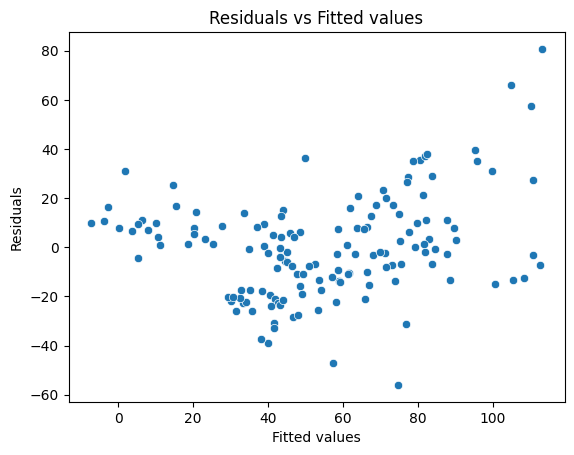

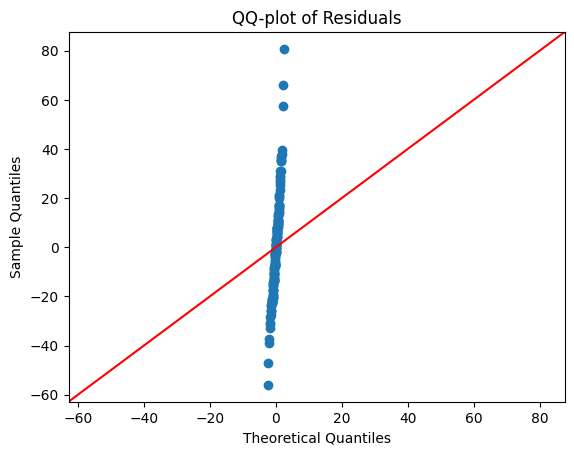

Breusch-Pagan test p-value: 0.4417879620598312
No heteroscedasticity detected. The variance of residuals is constant.
Shapiro-Wilk test p-value: 0.00495199766010046
Residuals are not normally distributed.
        feature       VIF
0     Intercept  3.244444
1  session[T.2]  1.368037
2  session[T.3]  1.360426
3  session[T.4]  1.289193
AIC: 1395.5447532910455
BIC: 1410.4627863995872

--- Per-session summary (PYY, filtered on df_lmer pairs) ---
         n_rows  n_participants   mean_PYY     sd_PYY
session                                              
1            45              45  27.979556  18.936086
2            39              39  67.240769  42.144898
3            37              37  66.817027  38.540375
4            25              25  65.424800  35.650052


In [70]:
# ===============================
# PYY ~ session (filtered df_lmer)
# ===============================

analysis_df = df_PYY_lmer.copy()

print("\n--- N per session (PYY, filtered on df_lmer pairs) ---")
print(
    analysis_df.groupby("session")
    .agg(
        n_rows=("PYY", "size"),
        n_participants=("id_participant", "nunique")
    )
    .sort_index()
)

# Define the formula
formula = "PYY ~ session"

# Fit the mixed model
mixed_model = smf.mixedlm(
    formula,
    analysis_df,
    groups=analysis_df["id_participant"],
    re_formula="1"
)
mixed_model_fit = mixed_model.fit()

# Print the summary of the model
print(mixed_model_fit.summary())

# Wald test for global session effect
print("\n--- Wald Test (Global Session Effect) ---")
wald_result = mixed_model_fit.wald_test_terms(skip_single=False, scalar=True)
print(wald_result)

# Residuals vs fitted values
residuals = mixed_model_fit.resid
fitted_values = mixed_model_fit.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")
plt.show()

# QQ-plot of residuals
sm.qqplot(residuals, line="45")
plt.title("QQ-plot of Residuals")
plt.show()

# Breusch-Pagan test for homoscedasticity
bp_test = het_breuschpagan(mixed_model_fit.resid, mixed_model_fit.model.exog)

# Extract the p-value
bp_pvalue = bp_test[1]
print(f"Breusch-Pagan test p-value: {bp_pvalue}")

if bp_pvalue < 0.05:
    print("Heteroscedasticity detected. The variance of residuals is not constant.")
else:
    print("No heteroscedasticity detected. The variance of residuals is constant.")

# Shapiro-Wilk test for normality of residuals
shapiro_test = stats.shapiro(mixed_model_fit.resid)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

if shapiro_test.pvalue < 0.05:
    print("Residuals are not normally distributed.")
else:
    print("Residuals are normally distributed.")

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = mixed_model_fit.model.exog_names
vif_data["VIF"] = [
    variance_inflation_factor(mixed_model_fit.model.exog, i)
    for i in range(mixed_model_fit.model.exog.shape[1])
]
print(vif_data)

# Number of parameters in the model
k = len(mixed_model_fit.params)

# Number of observations
n = mixed_model_fit.nobs

# Log-likelihood of the model
log_likelihood = mixed_model_fit.llf

# Calculate AIC and BIC
aic = 2 * k - 2 * log_likelihood
bic = np.log(n) * k - 2 * log_likelihood

print(f"AIC: {aic}")
print(f"BIC: {bic}")

# PYY: N, mean, SD per session
print("\n--- Per-session summary (PYY, filtered on df_lmer pairs) ---")
session_summary = (
    analysis_df.groupby("session")
    .agg(
        n_rows=("PYY", "size"),
        n_participants=("id_participant", "nunique"),
        mean_PYY=("PYY", "mean"),
        sd_PYY=("PYY", "std")
    )
    .sort_index()
)

print(session_summary)
# optional:
# print(session_summary.round(3))

## with final QC Ghreline = time (table 1)


--- N per session (Ghrelin Totale, filtered on df_lmer pairs) ---
         n_rows  n_participants
session                        
1            47              47
2            41              41
3            39              39
4            27              27
           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Ghrelin_Totale
No. Observations: 154     Method:             REML          
No. Groups:       47      Scale:              7333.2721     
Min. group size:  2       Log-Likelihood:     -905.9356     
Max. group size:  4       Converged:          Yes           
Mean group size:  3.3                                       
------------------------------------------------------------
              Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
------------------------------------------------------------
Intercept     276.542   14.666 18.855 0.000  247.797 305.288
session[T.2] -121.025   18.423 -6.569 0.000 -157.135 -84.916
session[T.3] -106.669

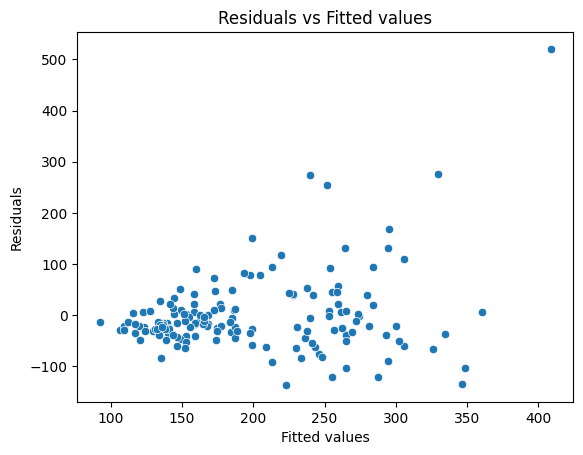

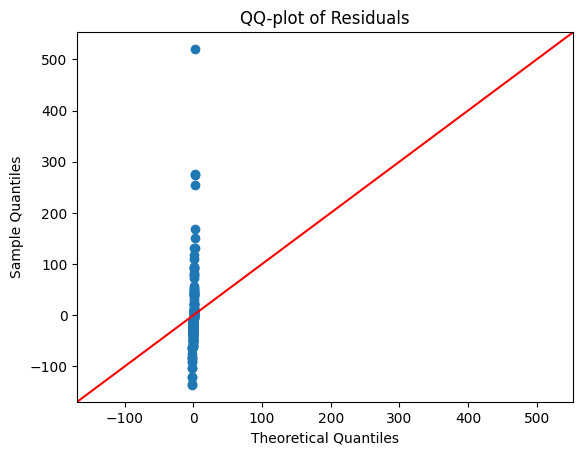

Breusch-Pagan test p-value: 0.24149842150651848
No heteroscedasticity detected. The variance of residuals is constant.
Shapiro-Wilk test p-value: 3.2494640252222e-14
Residuals are not normally distributed.
        feature       VIF
0     Intercept  3.276596
1  session[T.2]  1.373860
2  session[T.3]  1.366400
3  session[T.4]  1.298425
AIC: 1821.8712104801375
BIC: 1837.0559734922056

--- Per-session summary (Ghrelin Totale, filtered on df_lmer pairs) ---
         n_rows  n_participants  mean_Ghrelin_Totale  sd_Ghrelin_Totale
session                                                                
1            47              47           276.542340         132.030843
2            41              41           154.976341          62.098192
3            39              39           170.207179          93.508898
4            27              27           175.280741          93.005752


In [71]:
# ==========================================
# Ghrelin_Totale ~ session (filtered df_lmer)
# ==========================================

analysis_df = df_Ghrelin_lmer.copy()

print("\n--- N per session (Ghrelin Totale, filtered on df_lmer pairs) ---")
print(
    analysis_df.groupby("session")
    .agg(
        n_rows=("Ghrelin_Totale", "size"),
        n_participants=("id_participant", "nunique")
    )
    .sort_index()
)

# Define the formula
formula = "Ghrelin_Totale ~ session"

# Fit the mixed model
mixed_model = smf.mixedlm(
    formula,
    analysis_df,
    groups=analysis_df["id_participant"],
    re_formula="1"
)
mixed_model_fit = mixed_model.fit()

# Print the summary of the model
print(mixed_model_fit.summary())

# Wald test for global session effect
print("\n--- Wald Test (Global Session Effect) ---")
wald_result = mixed_model_fit.wald_test_terms(skip_single=False, scalar=True)
print(wald_result)

# Residuals vs fitted values
residuals = mixed_model_fit.resid
fitted_values = mixed_model_fit.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")
plt.show()

# QQ-plot of residuals
sm.qqplot(residuals, line="45")
plt.title("QQ-plot of Residuals")
plt.show()

# Breusch-Pagan test for homoscedasticity
bp_test = het_breuschpagan(mixed_model_fit.resid, mixed_model_fit.model.exog)

# Extract the p-value
bp_pvalue = bp_test[1]
print(f"Breusch-Pagan test p-value: {bp_pvalue}")

if bp_pvalue < 0.05:
    print("Heteroscedasticity detected. The variance of residuals is not constant.")
else:
    print("No heteroscedasticity detected. The variance of residuals is constant.")

# Shapiro-Wilk test for normality of residuals
shapiro_test = stats.shapiro(mixed_model_fit.resid)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

if shapiro_test.pvalue < 0.05:
    print("Residuals are not normally distributed.")
else:
    print("Residuals are normally distributed.")

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = mixed_model_fit.model.exog_names
vif_data["VIF"] = [
    variance_inflation_factor(mixed_model_fit.model.exog, i)
    for i in range(mixed_model_fit.model.exog.shape[1])
]
print(vif_data)

# Number of parameters in the model
k = len(mixed_model_fit.params)

# Number of observations
n = mixed_model_fit.nobs

# Log-likelihood of the model
log_likelihood = mixed_model_fit.llf

# Calculate AIC and BIC
aic = 2 * k - 2 * log_likelihood
bic = np.log(n) * k - 2 * log_likelihood

print(f"AIC: {aic}")
print(f"BIC: {bic}")

# Ghrelin Totale: N, mean, SD per session
print("\n--- Per-session summary (Ghrelin Totale, filtered on df_lmer pairs) ---")
session_summary = (
    analysis_df.groupby("session")
    .agg(
        n_rows=("Ghrelin_Totale", "size"),
        n_participants=("id_participant", "nunique"),
        mean_Ghrelin_Totale=("Ghrelin_Totale", "mean"),
        sd_Ghrelin_Totale=("Ghrelin_Totale", "std")
    )
    .sort_index()
)

print(session_summary)
# optional:
# print(session_summary.round(3))


## With final QC glp-1 = time (table 1)


--- N per session (GLP-1, filtered on df_lmer pairs) ---
         n_rows  n_participants
session                        
1            45              45
2            40              40
3            38              38
4            24              24
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: GLP_1_total
No. Observations: 147     Method:             REML       
No. Groups:       48      Scale:              3244.7652  
Min. group size:  2       Log-Likelihood:     -811.2708  
Max. group size:  4       Converged:          Yes        
Mean group size:  3.1                                    
---------------------------------------------------------
              Coef.   Std.Err.   z   P>|z| [0.025  0.975]
---------------------------------------------------------
Intercept      82.996   10.550 7.867 0.000 62.318 103.674
session[T.2]   53.679   12.583 4.266 0.000 29.017  78.341
session[T.3]   35.880   12.789 2.806 0.005 10.815  60.946
sessio

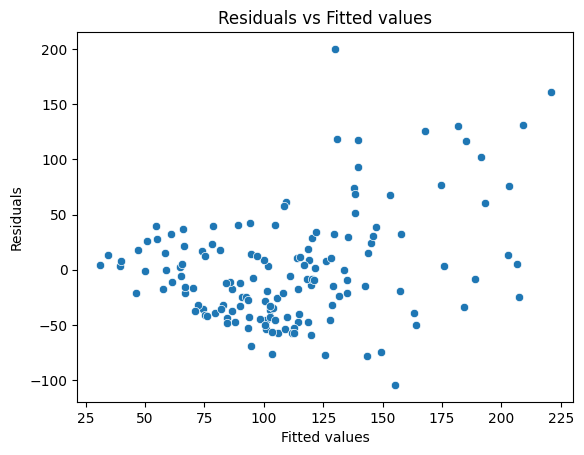

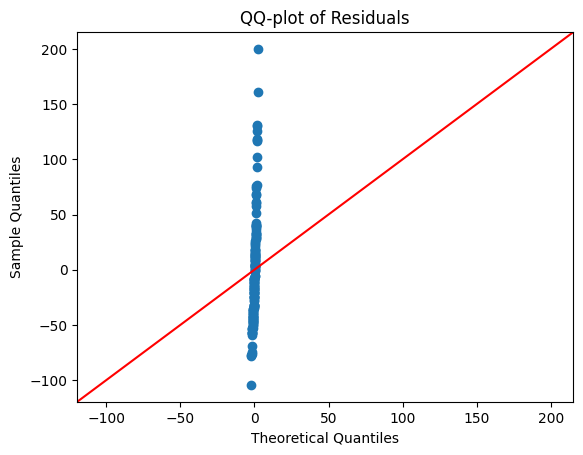

Breusch-Pagan test p-value: 0.4084569445113435
No heteroscedasticity detected. The variance of residuals is constant.
Shapiro-Wilk test p-value: 6.415085636035656e-07
Residuals are not normally distributed.
        feature       VIF
0     Intercept  3.266667
1  session[T.2]  1.374906
2  session[T.3]  1.367649
3  session[T.4]  1.282993
AIC: 1632.541562961705
BIC: 1647.4937258955988

--- Per-session summary (GLP-1, filtered on df_lmer pairs) ---
         n_rows  n_participants   mean_GLP1    sd_GLP1
session                                               
1            45              45   80.166667  46.343382
2            40              40  136.295000  83.579598
3            38              38  116.418421  73.884171
4            24              24  118.108333  81.788385


In [72]:
# =====================================
# GLP_1_total ~ session (filtered df_lmer)
# =====================================

analysis_df = df_GLP1_lmer.copy()

print("\n--- N per session (GLP-1, filtered on df_lmer pairs) ---")
print(
    analysis_df.groupby("session")
    .agg(
        n_rows=("GLP_1_total", "size"),
        n_participants=("id_participant", "nunique")
    )
    .sort_index()
)

# Define the formula
formula = "GLP_1_total ~ session"

# Fit the mixed model
mixed_model = smf.mixedlm(
    formula,
    analysis_df,
    groups=analysis_df["id_participant"],
    re_formula="1"
)
mixed_model_fit = mixed_model.fit()

# Print the summary of the model
print(mixed_model_fit.summary())

# Wald test for global session effect
print("\n--- Wald Test (Global Session Effect) ---")
wald_result = mixed_model_fit.wald_test_terms(skip_single=False, scalar=True)
print(wald_result)

# Residuals vs fitted values
residuals = mixed_model_fit.resid
fitted_values = mixed_model_fit.fittedvalues
sns.scatterplot(x=fitted_values, y=residuals)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted values")
plt.show()

# QQ-plot of residuals
sm.qqplot(residuals, line="45")
plt.title("QQ-plot of Residuals")
plt.show()

# Breusch-Pagan test for homoscedasticity
bp_test = het_breuschpagan(mixed_model_fit.resid, mixed_model_fit.model.exog)

# Extract the p-value
bp_pvalue = bp_test[1]
print(f"Breusch-Pagan test p-value: {bp_pvalue}")

if bp_pvalue < 0.05:
    print("Heteroscedasticity detected. The variance of residuals is not constant.")
else:
    print("No heteroscedasticity detected. The variance of residuals is constant.")

# Shapiro-Wilk test for normality of residuals
shapiro_test = stats.shapiro(mixed_model_fit.resid)
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

if shapiro_test.pvalue < 0.05:
    print("Residuals are not normally distributed.")
else:
    print("Residuals are normally distributed.")

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["feature"] = mixed_model_fit.model.exog_names
vif_data["VIF"] = [
    variance_inflation_factor(mixed_model_fit.model.exog, i)
    for i in range(mixed_model_fit.model.exog.shape[1])
]
print(vif_data)

# Number of parameters in the model
k = len(mixed_model_fit.params)

# Number of observations
n = mixed_model_fit.nobs

# Log-likelihood of the model
log_likelihood = mixed_model_fit.llf

# Calculate AIC and BIC
aic = 2 * k - 2 * log_likelihood
bic = np.log(n) * k - 2 * log_likelihood

print(f"AIC: {aic}")
print(f"BIC: {bic}")

print("\n--- Per-session summary (GLP-1, filtered on df_lmer pairs) ---")
session_summary = (
    analysis_df.groupby("session")
    .agg(
        n_rows=("GLP_1_total", "size"),
        n_participants=("id_participant", "nunique"),
        mean_GLP1=("GLP_1_total", "mean"),
        sd_GLP1=("GLP_1_total", "std")
    )
    .sort_index()
)

print(session_summary)

## bid on y-axis

In [73]:
# Fit LMM for GLP-1 (hormone as predictor of bid)
results_GLP1 = smf.mixedlm('bid ~ GLP_1_total + age + type_chx + IMC_baseline + sexeF', 
                           df_GI_bid_hi_pp_GLP1_no_outliers_session, 
                           groups=df_GI_bid_hi_pp_GLP1_no_outliers_session['id_participant'], 
                           re_formula='1').fit()

# Fit LMM for PYY (hormone as predictor of bid)
results_PYY = smf.mixedlm('bid ~ PYY + age + type_chx + IMC_baseline + sexeF', 
                          df_GI_bid_hi_pp_PYY_no_outliers_session, 
                          groups=df_GI_bid_hi_pp_PYY_no_outliers_session['id_participant']).fit()

# Fit LMM for Ghrelin Totale (hormone as predictor of bid)
results_Ghrelin = smf.mixedlm('bid ~ Ghrelin_Totale + age + type_chx + IMC_baseline + sexeF', 
                              df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session, 
                              groups=df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session['id_participant']).fit()

# Print summaries
print("="*80)
print("GLP-1 MODEL")
print("="*80)
print(results_GLP1.summary())

print("\n" + "="*80)
print("PYY MODEL")
print("="*80)
print(results_PYY.summary())

print("\n" + "="*80)
print("GHRELIN MODEL")
print("="*80)
print(results_Ghrelin.summary())

GLP-1 MODEL
          Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  bid      
No. Observations:  196      Method:              REML     
No. Groups:        64       Scale:               0.3283   
Min. group size:   1        Log-Likelihood:      -224.4537
Max. group size:   4        Converged:           Yes      
Mean group size:   3.1                                    
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        2.456    0.986  2.491 0.013  0.523  4.389
type_chx[T.2.0] -0.151    0.219 -0.686 0.493 -0.580  0.279
type_chx[T.3.0]  0.449    0.220  2.035 0.042  0.016  0.881
sexeF[T.1.0]    -0.170    0.203 -0.839 0.401 -0.569  0.228
GLP_1_total     -0.001    0.001 -1.592 0.111 -0.003  0.000
age              0.008    0.010  0.787 0.431 -0.012  0.028
IMC_baseline    -0.013    0.021 -0.609 0.543 -0.055  0.

## save hormones df to tsvs (for figure 2 analysis in R)

In [74]:
data_dir = "C:\\Users\\Patrick\\Gutbrain_R\\data"

df_GLP1_lmer.to_csv(
    f"{data_dir}/df_GI_bid_hi_pp_GLP1_no_outliers_session.tsv",
    sep="\t",
    index=False
)

df_PYY_lmer.to_csv(
    f"{data_dir}/df_GI_bid_hi_pp_PYY_no_outliers_session.tsv",
    sep="\t",
    index=False
)

df_Ghrelin_lmer.to_csv(
    f"{data_dir}/df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session.tsv",
    sep="\t",
    index=False
)

print("Three filtered hormone dataframes saved to:", data_dir)
print("GLP-1:", df_GLP1_lmer.shape)
print("PYY:", df_PYY_lmer.shape)
print("Ghrelin:", df_Ghrelin_lmer.shape)

Three filtered hormone dataframes saved to: C:\Users\Patrick\Gutbrain_R\data
GLP-1: (147, 46)
PYY: (146, 46)
Ghrelin: (154, 47)


In [75]:
# Check one of the models (e.g., GLP-1)
results = results_GLP1
hormone_var = 'GLP_1_total'

print("Intercept:", results.params['Intercept'])
print("Slope (beta):", results.params[hormone_var])
print("\nSE Intercept:", results.bse['Intercept'])
print("SE Slope:", results.bse[hormone_var])

print("\nCovariance matrix:")
print(results.cov_params())

# Check a specific point
x_test = 50  # Pick a value in the middle of your x range
se_fit = np.sqrt(results.bse['Intercept']**2 + 
                 x_test**2 * results.bse[hormone_var]**2 + 
                 2 * x_test * results.cov_params().loc['Intercept', hormone_var])
print(f"\nAt x={x_test}, SE of fitted value: {se_fit}")
print(f"95% CI width at x={x_test}: ±{1.96 * se_fit}")

Intercept: 2.456458112185273
Slope (beta): -0.0012872991906546956

SE Intercept: 0.9862544347616492
SE Slope: 0.0008085474480100815

Covariance matrix:
                 Intercept  type_chx[T.2.0]  type_chx[T.3.0]  sexeF[T.1.0]  \
Intercept         0.972698        -0.046506        -0.004455 -2.701398e-02   
type_chx[T.2.0]  -0.046506         0.048104         0.011829 -1.151090e-03   
type_chx[T.3.0]  -0.004455         0.011829         0.048600 -2.208736e-03   
sexeF[T.1.0]     -0.027014        -0.001151        -0.002209  4.128433e-02   
GLP_1_total      -0.000015        -0.000021        -0.000060 -9.677931e-07   
age              -0.003414        -0.000170         0.000875  5.578175e-04   
IMC_baseline     -0.017619         0.000992        -0.000979 -6.446032e-04   
Group Var         0.006568         0.003304         0.001429  5.712618e-04   

                  GLP_1_total       age  IMC_baseline  Group Var  
Intercept       -1.536927e-05 -0.003414 -1.761912e-02   0.006568  
type_chx[T.

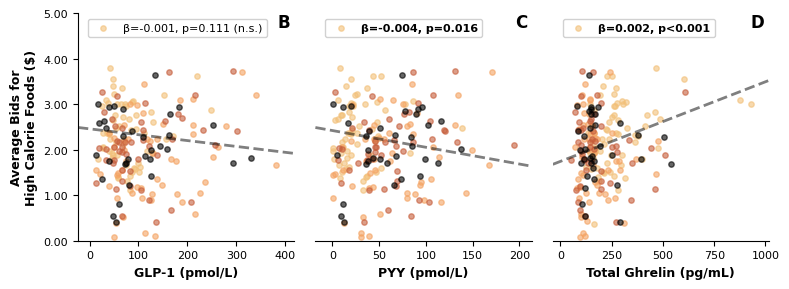


GI Hormone plots completed!


In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
from matplotlib import font_manager

# Create figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(8, 3))

# Define hormone variables, labels, dataframes, and results
hormone_vars = ['GLP_1_total', 'PYY', 'Ghrelin_Totale']
hormone_labels = ['GLP-1', 'PYY', 'Total Ghrelin']
hormone_x_labels = ['GLP-1 (pmol/L)', 'PYY (pmol/L)', 'Total Ghrelin (pg/mL)']
dataframes = [df_GI_bid_hi_pp_GLP1_no_outliers_session, 
              df_GI_bid_hi_pp_PYY_no_outliers_session, 
              df_GI_bid_hi_ac_Ghrelin_Totale_no_outliers_session]
results_list = [results_GLP1, results_PYY, results_Ghrelin]
panel_labels = ['B', 'C', 'D']  # Panel labels for each subplot

# Define colors per session
session_colors = {
    '1': "#F2C078",      # Light, warm peach-orange - Session 1
    '2': "#F4A261",      # More saturated orange - Session 2
    '3': "#C65D3A",      # Deep orange-red - Session 3
    '4': "#000000"       # Black anchor - Session 4
}

# Y-axis limits for bid
y_limits = (0, 5)

# Bonferroni correction threshold for 3 tests: 0.05/3 = 0.0167
bonferroni_threshold = 0.05 / 3

# Loop through each hormone variable
for idx, (hormone_var, hormone_label, x_label, df_hormone, results, panel_label) in enumerate(zip(hormone_vars, hormone_labels, hormone_x_labels, dataframes, results_list, panel_labels)):
    ax = axes[idx]
    
    # Get clean data (remove NaN)
    plot_data = df_hormone[['bid', hormone_var, 'session']].dropna()
    
    if len(plot_data) > 0:
        # Determine x-axis limits for this specific hormone variable
        x_min, x_max = plot_data[hormone_var].min(), plot_data[hormone_var].max()
        x_range = x_max - x_min
        x_limits = (x_min - 0.1 * x_range, x_max + 0.1 * x_range)
        
        # Extract beta coefficient for hormone from the results
        beta_hormone = results.params[hormone_var]
        beta_intercept = results.params['Intercept']
        
        # Get p-value
        p_value = results.pvalues[hormone_var]
        
        # Create legend label with beta and p-value
        if p_value < 0.001:
            p_text = 'p<0.001'
        else:
            p_text = f'p={p_value:.3f}'
        
        # Add (n.s.) if p >= Bonferroni threshold and set legend weight
        if p_value >= bonferroni_threshold:
            legend_label = f'β={beta_hormone:.3f}, {p_text} (n.s.)'
            legend_weight = 'normal'
        else:
            legend_label = f'β={beta_hormone:.3f}, {p_text}'
            legend_weight = 'bold'
        
        # Plot points colored by session
        for session in sorted(plot_data['session'].unique()):
            session_data = plot_data[plot_data['session'] == session]
            ax.scatter(session_data[hormone_var], session_data['bid'],
                      alpha=0.6, s=15, color=session_colors.get(str(int(session)), '#808080'))
        
        # Add line based on beta coefficient from the model
        x_line = np.linspace(x_limits[0], x_limits[1], 100)
        y_line = beta_intercept + beta_hormone * x_line
        
        ax.plot(x_line, y_line, color='black', alpha=0.5, linewidth=2, linestyle='--')
        
        # Position legend - raised to top
        legend = ax.legend([legend_label], fontsize=8, loc='upper left', bbox_to_anchor=(0.02, 1.0), framealpha=0.9)
        
        # Make legend text bold if significant
        for text in legend.get_texts():
            text.set_weight(legend_weight)
        
        # Add panel label in upper right corner - raised to top
        ax.text(0.98, 1.0, panel_label, transform=ax.transAxes,
                fontsize=12, fontweight='bold', va='top', ha='right')
        
        # Set x-limits specific to this variable
        ax.set_xlim(x_limits)
        
        # Set x-axis to have exactly 5 ticks
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    
    # Only add y-label and y-ticks to first subplot
    if idx == 0:
        ax.set_ylabel('Average Bids for\nHigh Calorie Foods ($)', fontsize=9, fontweight='bold')
        # Format y-axis to show 2 decimal places
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    else:
        # Hide y-axis for other subplots
        ax.set_yticklabels([])
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', which='both', left=False)
    
    # Add individual x-label for each subplot
    ax.set_xlabel(x_label, fontsize=9, fontweight='bold')
    
    # Set y-limits
    ax.set_ylim(y_limits)
    
    # Format axes with smaller font for tick labels (8pt)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("\nGI Hormone plots completed!")